# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [ ]:
# !pip install mat73 h5py

In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt

import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
import kagglehub

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# Download latest version
path = kagglehub.dataset_download("itshpark/data-driven-prediction-of-battery-cycle")

print("Path to dataset files:", path)

Path to dataset files: /Users/kjsoo/.cache/kagglehub/datasets/itshpark/data-driven-prediction-of-battery-cycle/versions/1


In [4]:
# 데이터 경로 설정 (kagglehub 다운로드 경로 사용)
# .mat 파일이 하위 폴더에 있을 수 있으므로 실제 위치를 탐색
DATA_DIR = next(
    (root for root, _, fnames in os.walk(path) if any(f.endswith('.mat') for f in fnames)),
    path
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_gb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_gb:.1f} GB)")

데이터 경로 : /Users/kjsoo/.cache/kagglehub/datasets/itshpark/data-driven-prediction-of-battery-cycle/versions/1
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [5]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [6]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [7]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [8]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [9]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [19]:
# Batch 1 품질 처리 (Severson et al. 공식 코드 'Load Data.ipynb' 기준)
B1_NOT_REACH_EOL = [8, 10, 12, 13, 22]                         # 80% 용량(0.88Ah)에 도달하지 못한 셀 → 제외
B1_CONTINUED     = {0: 662, 1: 981, 2: 1060, 3: 208, 4: 482}   # 다음 배치로 실험이 이어진 셀 → 수명에 더할 사이클 수

def clean_batch1(df):
    """Batch 1 summary DataFrame 정제"""
    out = df[df['cycle'] > 1]                                  # 첫 사이클은 원본에 측정값이 없어 0으로 채워져 있음
    out = out[~out['cell_id'].isin(B1_NOT_REACH_EOL)].copy()
    out['cycle_life'] += out['cell_id'].map(B1_CONTINUED).fillna(0).astype(int)
    # 아래 두 줄은 논문/공식 코드에 없는 자체 판단
    out.loc[out['IR'] == 0, 'IR'] = np.nan                                  # IR 측정 누락 (cycle 12~13, 848~909)
    out.loc[(out['cell_id'] == 18) & (out['cycle'] <= 53), 'IR'] = np.nan   # 셀 18 : cycle 2~53의 IR이 같은 값으로 고정
    return out.reset_index(drop=True)

_df = extract_summary(batch)   # 원본 백업
df  = clean_batch1(_df)

print(f"DataFrame shape : {_df.shape} → {df.shape}")
print(f"배터리 셀 수    : {_df['cell_id'].nunique()} → {df['cell_id'].nunique()}")
print(f"IR 결측 처리    : {df['IR'].isna().sum()}개")
df.head()


DataFrame shape : (38811, 11) → (34300, 11)
배터리 셀 수    : 46 → 41
IR 결측 처리    : 70개


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,2,1852,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
1,0,3,1852,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
2,0,4,1852,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
3,0,5,1852,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442
4,0,6,1852,3.6C(80%)-3.6C,1.073576,1.073491,0.016623,35.711758,31.961062,29.752932,13.340835


In [20]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,34300.000,34300.000,34300.000,34300.000,34300.000,34230.000,34300.000,34300.000,34300.000,34300.000
mean,21.780,441.940,1000.421,1.045,1.045,0.017,37.319,33.410,30.596,11.569
std,13.898,278.963,441.035,0.048,0.051,0.001,2.508,1.635,1.189,4.783
min,0.000,2.000,534.000,0.880,0.880,0.015,25.938,25.038,23.817,8.897
25%,9.000,211.000,709.000,1.035,1.035,0.017,35.936,32.380,29.881,10.483
50%,23.000,420.000,862.000,1.062,1.062,0.017,37.566,33.447,30.385,11.208
75%,34.000,635.000,1051.000,1.076,1.076,0.017,39.102,34.485,31.180,12.096
max,45.000,1226.000,2237.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [21]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id             0
cycle               0
cycle_life          0
charging_policy     0
QD                  0
QC                  0
IR                 70
Tmax                0
Tavg                0
Tmin                0
chargetime          0
dtype: int64


In [22]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 41
충전 정책 종류 : 22


## EDA(Basic)

### 1. Cycle Life 분포

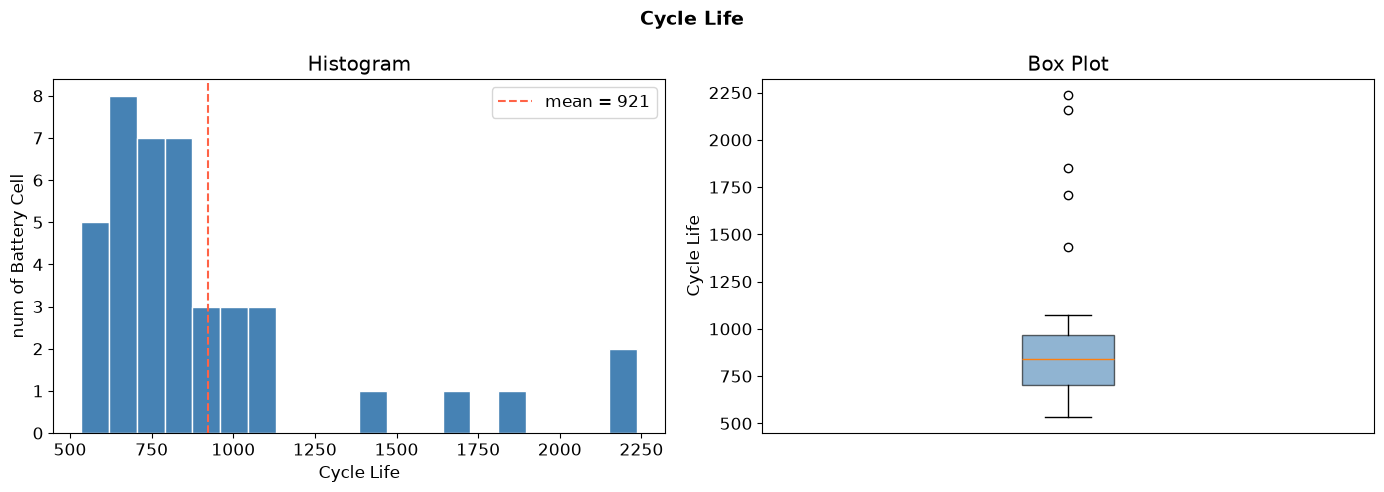

count      41.0
mean      921.3
std       400.8
min       534.0
25%       702.0
50%       842.0
75%       966.0
max      2237.0
Name: cycle_life, dtype: float64


In [24]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 921 사이클, 중앙값 842 사이클 (단명 534 ~ 장수 2237)
- 평균 > 중앙값 (차이 약 80 사이클), 왜도 2.14 -> 오른쪽으로 긴 꼬리를 가진 분포. 소수의 장수 셀이 평균을 끌어올림
- IQR 통해 절반의 배터리가 702 ~ 966 범위에 집중 
- 41개 중 36개가 534 ~ 1074 범위, 나머지 5개는 1434 ~ 2237로 떨어져 있음 (1074 ~ 1434 사이는 비어 있음)

[plot]
- Histogram : 600 ~ 900 구간에 가장 몰려 있고, 1100 이후는 비어 있다가 1400 ~ 2200대에 5개 셀이 흩어져 분포. 정규분포가 아님 
- Box plot : 
    - 상자(IQR) = 702 ~ 966, 폭 264
    - Upper whisker = |75%(966) - 1074| = 108
    - Lower whisker = |25%(702) - min(534)| = 168
    - whisker 밖 이상치 5개 : 1434, 1709, 1852, 2160, 2237
- 이상치 5개는 모두 가장 느린 충전 정책 2종 : `3.6C(80%)-3.6C` 3개, `4C(80%)-4C` 2개 -> 측정 오류가 아니라 충전 조건이 만든 실제 장수 셀이므로 제거 대상이 아님
- 이상치를 제외하면 whisker는 위아래가 비슷함 -> 대부분의 셀은 534 ~ 1074 범위에 비교적 고르게 분포
- 느린 충전 조건의 5개 셀 사이에서도 수명이 1434 ~ 2237로 크게 벌어짐 -> 같은 정책 안에서도 장수 셀의 수명 편차가 큼

[to modeling]
- target이 오른쪽으로 치우쳐 있으므로 로그 변환 검토 (원논문도 log(cycle_life)를 예측)
- 장수 셀이 5개뿐이고 값의 범위가 넓어 예측 난이도가 높고, 이 셀들이 MAPE와 계수 추정에 큰 영향을 줄 수 있음 -> 장수 셀 포함/제외에 따른 성능 차이와 residual 분석 필요
- Hold-out 분할 시 장수 셀 5개가 한쪽에 몰리지 않도록 수명 구간을 고려해 나눌 것
- Classification 선택 시 : 550 사이클 미만인 셀이 1개(534)뿐이라 Batch 1만으로는 단수명 클래스를 학습하기 어려움

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

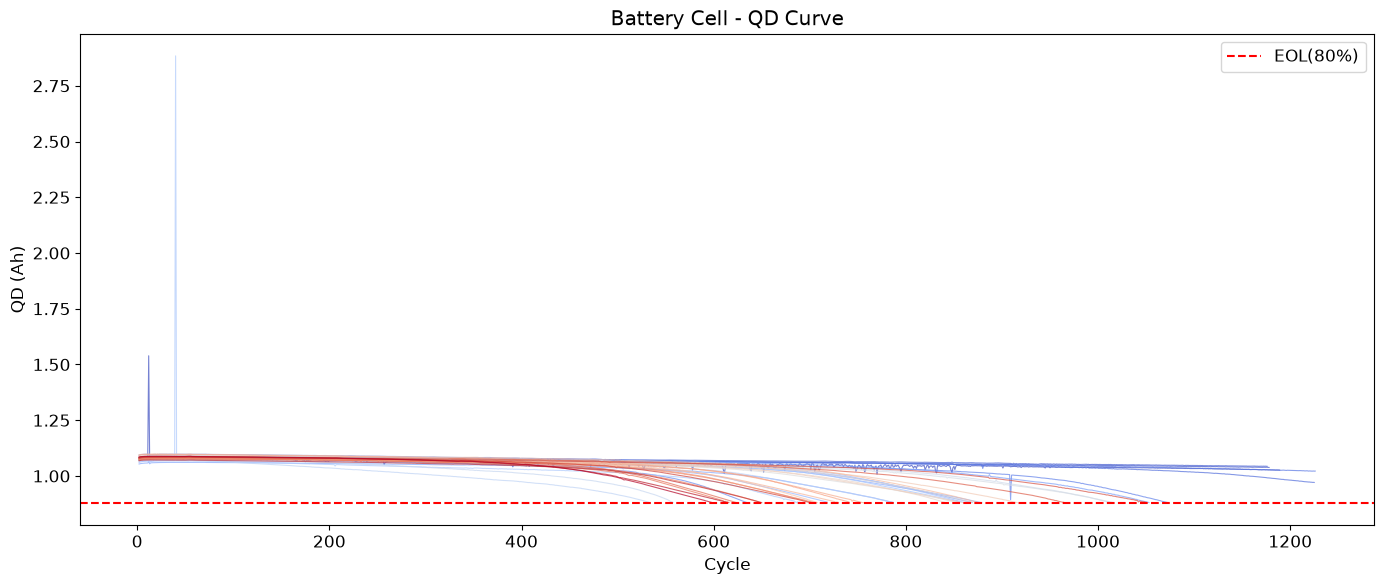

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

# nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
## 공칭 용량 1.1Ah의 80%
ax.axhline(y=0.88, # * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0795 Ah
필터 범위          : 0.8636 ~ 1.2954 Ah
제거된 행 수       : 2 (0.01%)


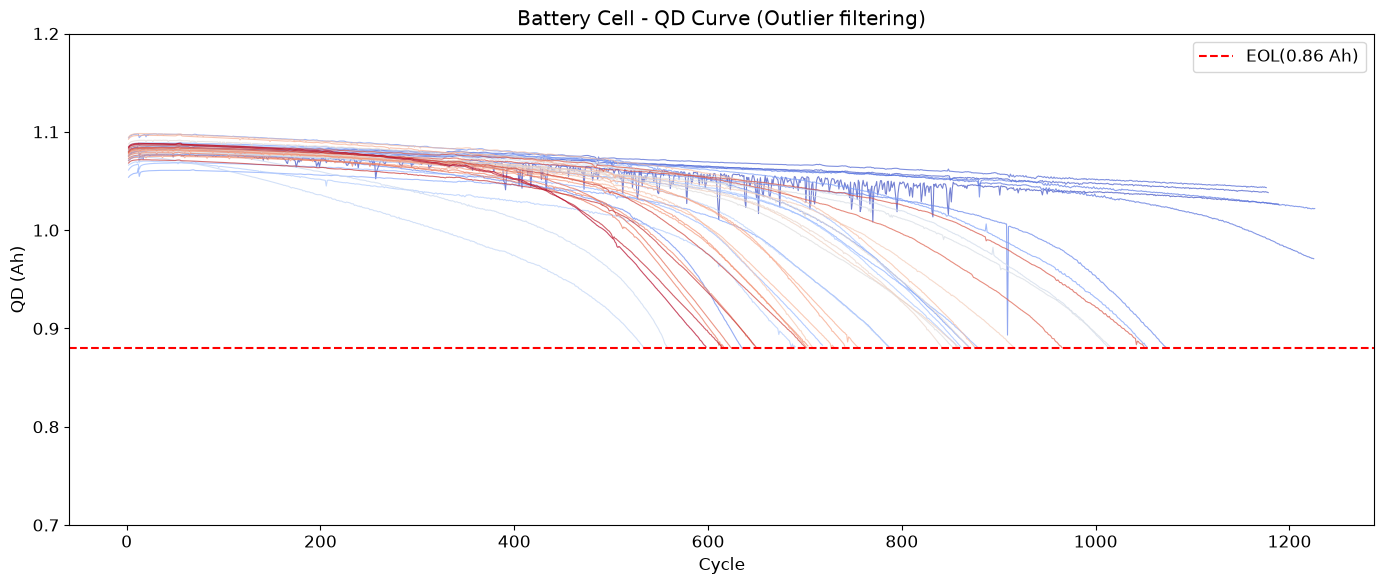

In [ ]:
# # Outlier 필터링 후 열화 곡선 

# # 1. 정상 용량 범위 정의
# nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
# lower   = nominal * 0.80 # cycle 2로 사전에 우리가 걸러서 필요 x
# upper   = nominal * 1.20

# print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
# print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# # 2. 필터링
# df_clean = df[df['QD'].between(lower, upper)].copy()
# print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# # 3. 시각화
# fig, ax = plt.subplots(figsize=(14, 6))

# cell_ids = df_clean['cell_id'].unique()
# colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

# for i, cid in enumerate(cell_ids):
#     sub = df_clean[df_clean['cell_id'] == cid]
#     ax.plot(sub['cycle'], sub['QD'],
#             color=colors[i], linewidth=0.8, alpha=0.7)

# ax.axhline(y=0.88, color='red', linestyle='--', # 동일하게 0.88 Ah 기준
#            linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
# ax.set_xlabel('Cycle')
# ax.set_ylabel('QD (Ah)')
# ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
# ax.set_ylim(0.7, 1.2)
# ax.legend()
# plt.tight_layout()
# plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 달느 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

초기 방전 용량(중앙값) : 1.0795 Ah
필터 범위              : 0.8636 ~ 1.2954 Ah
제거된 행 수           : 2 (0.01%)


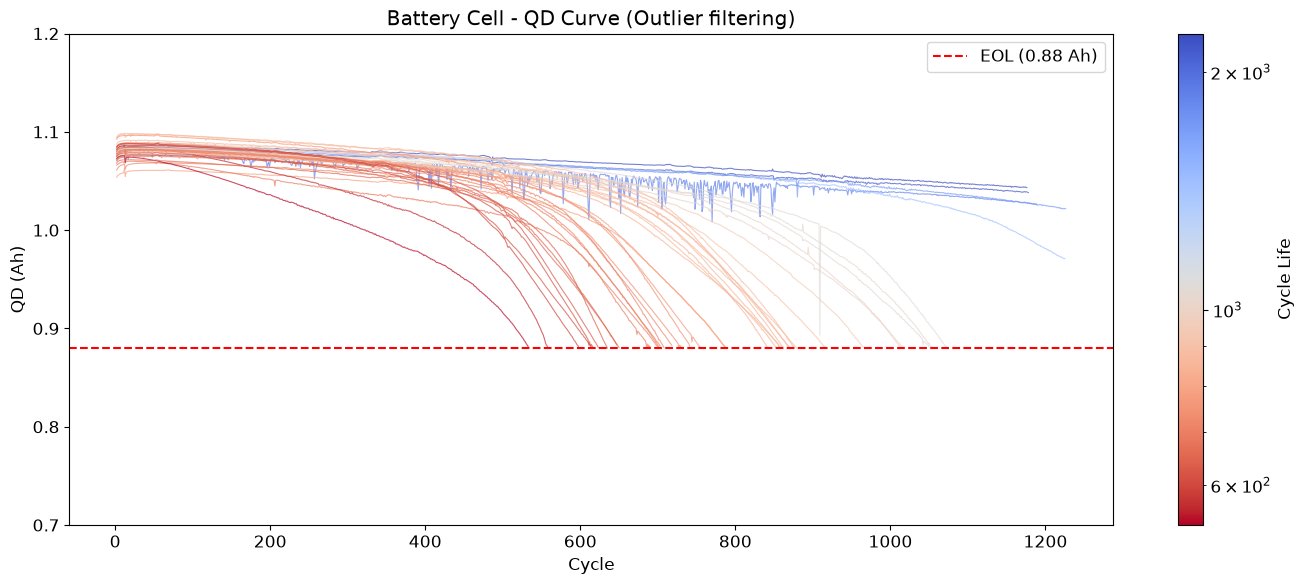

In [26]:
# Outlier 필터링 후 열화 곡선 
from matplotlib.colors import LogNorm

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"초기 방전 용량(중앙값) : {nominal:.4f} Ah")
print(f"필터 범위              : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수           : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화 (색 = cycle life, 파랑: 장수 / 빨강: 단명)
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
life = df_clean.drop_duplicates('cell_id').set_index('cell_id')['cycle_life']
norm = LogNorm(life.min(), life.max())

for cid in cell_ids:
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=cm.coolwarm_r(norm(life[cid])), linewidth=0.8, alpha=0.7)

ax.axhline(y=0.88, color='red', linestyle='--',
           linewidth=1.5, label='EOL (0.88 Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='coolwarm_r'), ax=ax, label='Cycle Life')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()


[plot] - 색 = cycle life (파랑 : 장수 / 빨강 : 단명, 로그 스케일)
- cycle 2 ~ 100 : 빨강과 파랑이 한 덩어리로 겹쳐 있어 색으로 구분되지 않음
    - 단수명 셀(700 미만, 10개)과 장수명 셀(1000 이상, 10개)의 평균 용량 차이 : cycle 2에서 0.001 Ah, cycle 100에서 0.006 Ah
    - 같은 시점 셀 간 용량 범위는 0.04 Ah -> 수명에 따른 차이가 셀 간 편차에 묻힘
    - 초기 용량이 가장 높은 5개 셀의 수명은 757 ~ 876으로 중간 수준, 최장수 그룹인 셀 0(수명 1852)은 초기 용량이 하위 5번째 -> 초기 용량이 높다고 오래 가지 않음
- cycle 100 ~ 400 : 빨간 곡선부터 아래로 벌어지기 시작하지만 색이 아직 섞여 있음
    - 용량과 수명의 순위 상관(Spearman) : cycle 2에서 0.09, cycle 100에서 0.33, cycle 200에서 0.43
- cycle 400 ~ : 색 순서대로 정렬됨. 빨강 -> 주황 -> 회색 -> 파랑 순으로 EOL에 도달
    - 순위 상관 : cycle 400에서 0.81, cycle 500에서 0.91 -> 용량이 수명을 반영하는 것은 열화가 이미 진행된 뒤
- 곡선 모양은 수명과 무관하게 비슷함 : 평탄 구간 뒤에 급락(knee)
    - 용량이 1.0 Ah 아래로 내려간 뒤 EOL까지 걸리는 사이클 : 전체 91 ~ 211, 단수명 셀 114 / 장수명 셀 169 (중앙값)
    - 수명 차이는 급락 구간의 길이가 아니라 급락이 시작되는 시점에서 생김
- 측정 노이즈 : 셀 0(수명 1852)은 cycle 257 ~ 851 구간에 아래로 튀는 값이 57회, 셀 5(수명 1074)는 cycle 909에서 0.89 Ah까지 한 번 튐. 필터 범위 안이라 제거되지 않고 남아 있음

[to modeling]
- 초기 100 사이클의 용량(QD) 수준은 수명 순위를 거의 설명하지 못함 (순위 상관 0.33 이하) -> QD 값 자체는 주 피처로 부적합
- 수명을 결정하는 것은 knee의 시작 시점인데 초기 100 사이클에는 아직 나타나지 않음 -> 용량 곡선에 드러나지 않는 초기 신호가 필요 -> 전압 곡선의 변화 ΔQ(V) 확인
- 사이클 단위 값에 튀는 측정값이 섞여 있으므로, 단일 사이클 값보다 구간 통계(중앙값, 기울기 등)나 평활화한 값을 피처로 사용


### 3. 내부 저항(IR) 변화 - 열화 지표

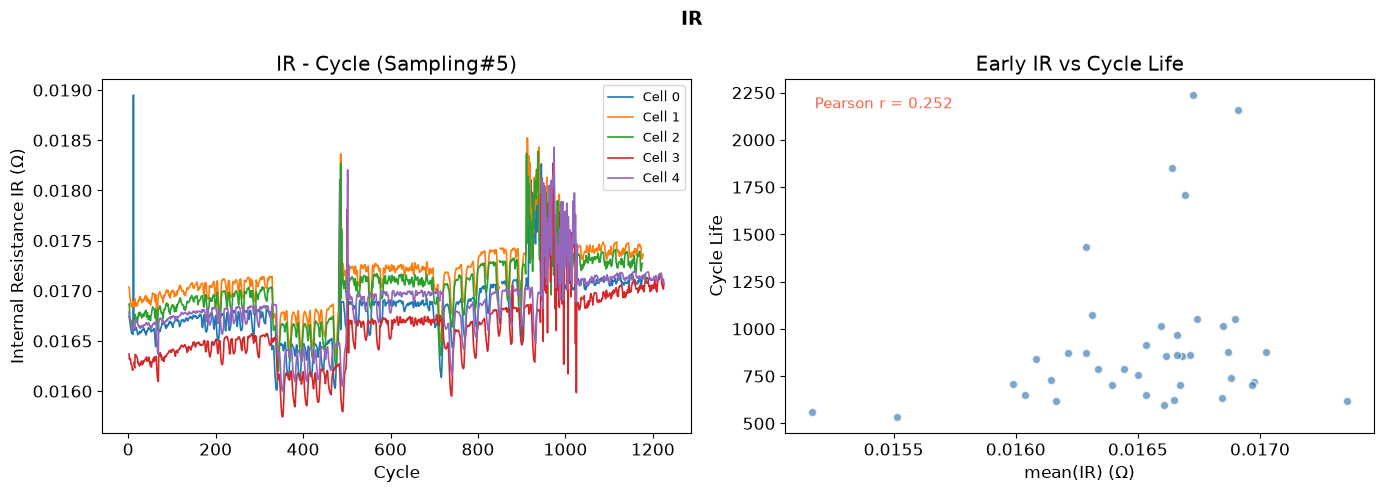

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

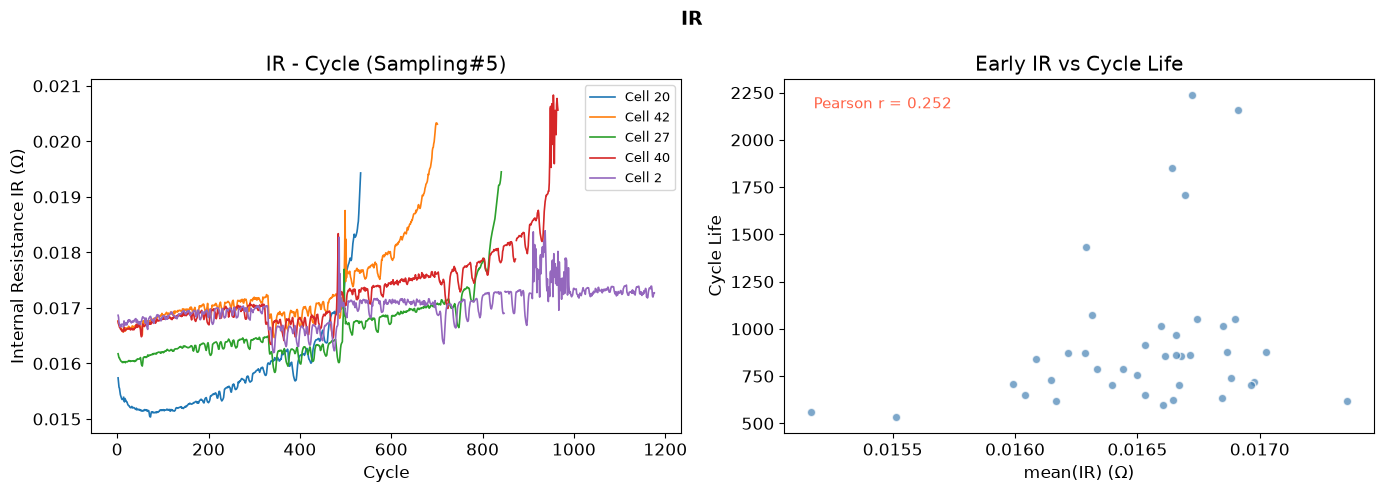

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cycle_life_df.sort_values('cycle_life')['cell_id'].iloc[[0, 10, 20, 30, 40]]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling (수명 534 / 702 / 842 / 966 / 2237인 셀 20 / 42 / 27 / 40 / 2)
- IR은 초기에 평탄하거나 약간 감소하다가 수명 후반에 뚜렷하게 상승함
    - EOL에 도달한 4개 셀 : 초기 0.0154 ~ 0.0166 Ω -> 말기 0.0183 ~ 0.0208 Ω (+18 ~ 24%)
    - 수명 2237인 셀 2 : 1176 사이클까지 +3.6%에 그침 (이후 구간 데이터 없음)
- 상승이 시작되는 시점은 수명이 짧은 셀일수록 빠름 : 셀 20은 약 100 사이클, 셀 42는 약 550, 셀 27은 약 750, 셀 40은 약 900 사이클부터 급상승 -> 용량 곡선의 knee와 같은 구조
- 전체 셀 기준 : EOL에 도달한 36개 셀 중 35개에서 IR 상승, 상승폭 중앙값 19% -> 용량 감소폭(약 19%)과 비슷한 수준
- 초기 100 사이클의 IR 변화는 중앙값이 거의 0이고 절반 정도의 셀은 오히려 감소 -> 초기 구간에서는 열화 신호가 약함
- 약 330, 490 사이클에서 5개 셀이 동시에 튐 -> 셀의 변화가 아니라 측정 장비/환경 요인으로 판단
- IR이 0으로 기록된 값(cycle 12 ~ 13, 848 ~ 909의 18개)은 측정 누락으로 판단해 결측 처리함

[plot] - correlation 
- 초기 10 사이클 평균 IR과 cycle life의 상관계수는 0.252 (40개 셀) -> 약한 양의 상관
- 초기 IR이 가장 낮은 두 셀(가장 빠른 충전 정책 `5.4C(80%)-5.4C`)이 수명도 가장 짧아 상관계수에 큰 영향을 줌 -> 전체적인 경향으로 보기 어려움
- 셀 18은 cycle 2 ~ 53의 IR이 같은 값으로 고정되어 있어 결측 처리 후 제외. 포함하면 상관계수가 0.09로 낮아짐
- 초기 IR의 셀 간 편차가 작음 (평균 0.0166 Ω, 변동계수 4%) -> 수명 차이(534 ~ 2237)를 설명하기에는 변별력이 부족

[to modeling]
- IR은 열화와 함께 상승하는 지표이지만, 상승이 수명 후반에 나타나므로 초기 IR 단독으로는 target variable을 설명할 수 없음
- 초기 구간에서의 IR 변화(예 : cycle 100 - cycle 2)나 최소 IR 등 파생변수를 다른 변수와 함께 사용하는 방안 검토 (원논문도 동일한 IR 피처를 사용)
- 여러 셀이 동시에 튀는 구간과 결측이 있으므로, 단일 사이클 값보다 구간 통계(중앙값 등)를 사용하고 결측을 건너뛰도록 계산


### 4. 충전 정책(C-rate)과 수명의 관계

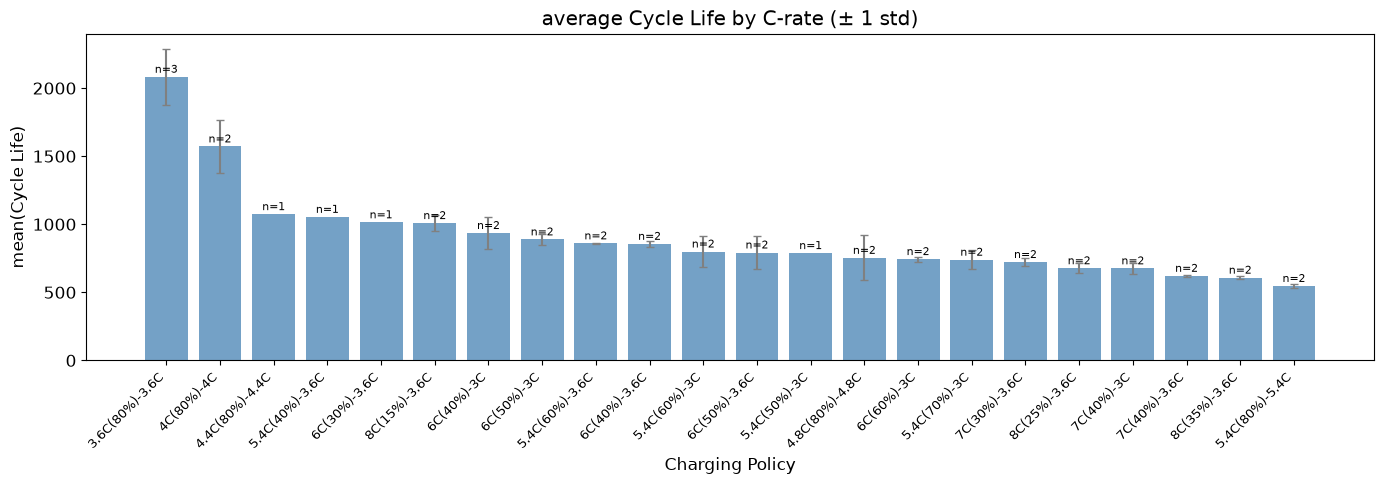

In [29]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 충전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `C1(Q1%)-C2` : 0% -> 80% 구간의 충전 방식 (80% -> 100%는 모든 셀이 동일하게 1C로 충전)
    - `C1` : 1단계. 0% -> Q1%까지의 충전 속도
    - `(Q1%)` : 전환 기준. 이 충전량에 도달하면 속도 변경
    - `C2` : 2단계. Q1% -> 80%까지의 충전 속도
- 예시 
    - `6C(40%)-3C` : 40%까지 6C, 이후 80%까지 3C
    - `4C(80%)-4C` : 80%까지 4C 한 가지 속도로 충전 (1단계 정책)
    - `5.4C(80%)-5.4C` : 80%까지 5.4C로 충전 -> 가장 빠른 정책, 수명 최단
- 평균 충전 속도 (자체 정의) : 0% -> 80%를 채우는 데 걸린 시간으로 환산한 C-rate. 이름의 숫자가 커도 그 속도를 쓰는 구간이 짧으면 평균은 낮음
    - 예 : `8C(15%)-3.6C`는 평균 4.0C로 `4C(80%)-4C`와 같음 (실제 충전 시간도 두 정책 모두 약 12분)
    - 원논문은 같은 내용을 0% -> 80% 충전 시간(9 ~ 13.3분)으로 표현



[plot]
- 정책 22종, 정책당 셀 1 ~ 3개 (2개인 정책이 17종, 1개인 정책 4종은 오차 막대 없음)
- 평균 충전 속도가 느릴수록 수명이 김 
    - 상위 : `3.6C(80%)-3.6C` 평균 2083 (평균 3.6C, 가장 느림), `4C(80%)-4C` 평균 1572 (평균 4.0C)
    - 중위 (약 1000) : `4.4C(80%)-4.4C`, `5.4C(40%)-3.6C`, `6C(30%)-3.6C`, `8C(15%)-3.6C`
    - 하위 (약 550 ~ 620) : `5.4C(80%)-5.4C` 평균 547 (평균 5.4C, 가장 빠름), `8C(35%)-3.6C`, `7C(40%)-3.6C`
    - 평균 충전 속도와 수명의 상관계수 -0.74 (순위 상관 -0.61), 80%까지의 충전 시간과는 +0.79
    - 상위 2개 정책과 3위 사이에 약 500 사이클의 간격이 있음 -> 평균 4.0C 이하에서 수명이 크게 늘어남
- 정책 이름의 C-rate 숫자만으로는 수명을 판단할 수 없음
    - `8C(15%)-3.6C`는 8C를 쓰지만 15%까지만 사용 -> 평균 1009로 상위권
    - 1단계 속도와 수명의 상관은 -0.66, 2단계 속도와는 -0.01 -> 2단계 속도 자체보다 빠른 1단계를 얼마나 오래 쓰는지가 중요
- 빠른 1단계 구간이 길수록 수명이 짧아짐 (같은 속도 조합에서 전환 기준만 다른 경우)
    - `8C(15%)-3.6C` 1009 -> `8C(25%)-3.6C` 677 -> `8C(35%)-3.6C` 608
    - `6C(40%)-3C` 936 -> `6C(50%)-3C` 889 -> `6C(60%)-3C` 744
- 평균 충전 속도가 같아도 충전 패턴에 따라 수명이 다름
    - 평균 4.0C : `4C(80%)-4C` 1572 vs `8C(15%)-3.6C` 1009 vs `6C(40%)-3C` 936 -> 일정한 속도로 충전한 쪽이 더 김
- 같은 정책 안에서도 셀 간 차이가 있음 : 2개 셀인 정책 17종의 수명 차이는 중앙값 56 사이클(약 7.5%), 최대 275 사이클(`4C(80%)-4C` : 1434 vs 1709)
- Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용과 방향이 일치 (이 데이터로 원인까지 확인한 것은 아님)
- 정책당 셀이 1 ~ 3개뿐이므로 개별 정책 간 비교는 "경향성" 수준으로 해석해야 함

[to modeling]
- 충전 조건은 수명과 뚜렷한 관계가 있음 -> 피처로 반영
- 정책명을 범주형으로 쓰기는 어려움 : 41개 셀에 22종이라 정책당 표본이 부족하고, 학습에 없던 정책에는 적용할 수 없음 -> 평균 충전 속도, 충전 시간, 1단계 속도, 전환 기준 등 수치형으로 변환해 사용
- 충전 시간은 summary에 사이클별로 기록되어 있어 초기 사이클만으로 계산 가능 (원논문도 초기 5 사이클의 평균 충전 시간을 피처로 사용)
- 같은 정책 안에서도 수명이 최대 275 사이클 차이 -> 충전 조건만으로는 설명되지 않는 셀 고유의 차이가 있음 -> 셀별 초기 신호(ΔQ(V) 등)와 함께 사용
- Hold-out 분할 시 같은 정책의 셀이 학습과 검증에 나뉘어 들어가면 검증 성능이 실제보다 좋게 나올 수 있음 -> 정책 단위로 묶어서 분할하는 방안 검토

### 5. 상관관계 히트맵

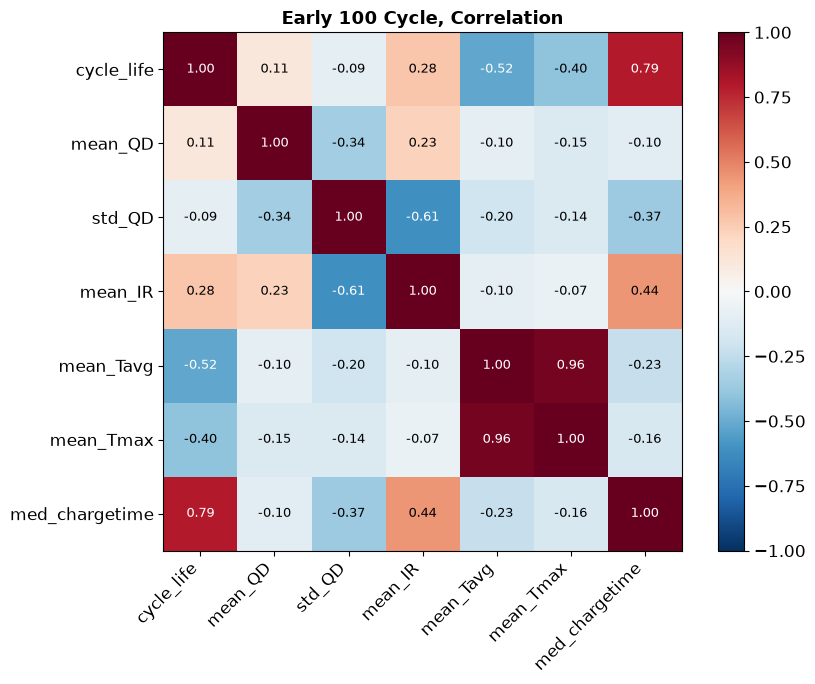


[cycle_life Corr Rank]
med_chargetime    0.790
mean_Tavg        -0.520
mean_Tmax        -0.400
mean_IR           0.278
mean_QD           0.113
std_QD           -0.092
Name: cycle_life, dtype: float64


In [30]:
# 배터리별 초기 100 사이클 평균 집계
early = df_clean[df_clean['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    med_chargetime = ('chargetime', 'median'),
).reset_index(drop=True)


corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

In [31]:
print(early[early['cycle_life'] < 1400].corr()['cycle_life'].drop('cycle_life').round(3))


mean_QD           0.250
std_QD           -0.394
mean_IR           0.337
mean_Tavg        -0.173
mean_Tmax        -0.163
med_chargetime    0.571
Name: cycle_life, dtype: float64


[correlation] - 초기 100 사이클 요약값과 cycle life (41개 셀)
- `med_chargetime` (+0.79) : 가장 강한 관계. 충전 시간이 길수록(= 느리게 충전할수록) 수명이 김 -> 앞의 충전 정책 분석과 같은 결과
- `mean_Tavg` (-0.52), `mean_Tmax` (-0.40) : 온도가 높을수록 수명이 짧은 경향
    - 다만 수명이 가장 긴 5개 셀을 빼면 -0.17, -0.16으로 약해짐 -> 이 상관은 느리게 충전한 장수 셀 5개가 대부분 만든 것
    - 충전 시간과 평균 온도의 상관도 -0.23으로 약함 -> "빠른 충전 -> 발열 -> 열화 가속"이라는 경로는 이 데이터의 요약값만으로는 확인되지 않음
- `mean_IR` (+0.28), `mean_QD` (+0.11), `std_QD` (-0.09) : 약하거나 거의 없음 -> 열화 곡선, IR 분석에서 확인한 것과 같이 초기 구간의 용량·저항 수준은 수명을 설명하지 못함
    - 셀이 41개일 때 상관계수의 절댓값이 약 0.31보다 작으면 통계적으로 유의하지 않음 -> 이 세 개는 우연으로도 나올 수 있는 크기
- 다중공선성
    - `mean_Tavg` vs `mean_Tmax` : 0.96 -> 사실상 같은 정보
    - `std_QD` vs `mean_IR` : -0.61
- 집계 방식 : 용량 스파이크 2행을 제외한 데이터를 사용했고, 충전 시간은 3개 셀의 cycle 13에 약 419분으로 기록된 값(정상 약 11분)이 있어 평균 대신 중앙값을 사용

[to modeling]
- 초기 100 사이클의 단순 요약값(평균, 표준편차) 중 수명과 강하게 연관된 것은 충전 시간뿐 -> 요약 통계만으로는 피처가 부족하고, 전압 곡선 기반 피처 ΔQ(V)가 필요
- 충전 시간은 셀의 상태가 아니라 실험 조건(충전 정책)을 나타내는 값 -> 같은 조건에서 셀마다 다른 수명은 설명하지 못하므로 셀별 신호와 함께 사용
- `mean_Tavg`와 `mean_Tmax`는 둘 중 하나만 쓰거나 규제가 있는 모델을 사용
- 셀이 41개뿐이므로 피처 수를 적게 유지하고 규제 선형 모델을 우선 후보로 검토 (원논문도 elastic net 사용)
- 상관계수는 선형 관계만 보므로 비선형 패턴은 산점도로 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

In [ ]:
# ===== 3개 배치 빠른 로딩 (h5py로 필요한 부분만 읽음) =====
import h5py
from matplotlib.colors import LogNorm

BATCH_FILES = {
    'Batch 1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'Batch 2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'Batch 3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
# 제외 셀 : Batch 1, 3은 원논문 공식 코드 기준 / Batch 2는 cycle_life가 없는 실험용 셀(VarCharge, SLOWCYCLE)
DROP_CELLS = {'Batch 1': [8, 10, 12, 13, 22], 'Batch 2': [], 'Batch 3': [2, 23, 32, 37, 42, 43]}
B1_CONTINUED = {0: 662, 1: 981, 2: 1060, 3: 208, 4: 482}

def load_batch_fast(name):
    """summary 전체 + cycle 10, 100의 Qdlin만 읽어 (사이클 단위 df, 셀별 ΔQ(V) dict, Vdlin) 반환"""
    f = h5py.File(os.path.join(DATA_DIR, BATCH_FILES[name]), 'r')
    b = f['batch']
    vdlin = np.array(f[b['Vdlin'][0, 0]]).ravel()
    frames, dq = [], {}
    for i in range(b['summary'].shape[0]):
        cl = float(np.array(f[b['cycle_life'][i, 0]]).ravel()[0])
        if i in DROP_CELLS[name] or np.isnan(cl):
            continue
        if name == 'Batch 1':
            cl += B1_CONTINUED.get(i, 0)
        s = f[b['summary'][i, 0]]
        g = lambda k: np.array(s[k]).ravel()
        d = pd.DataFrame({
            'batch': name, 'cell_id': i, 'cycle': g('cycle').astype(int), 'cycle_life': int(cl),
            'charging_policy': np.array(f[b['policy_readable'][i, 0]]).tobytes()[::2].decode(),
            'QD': g('QDischarge'), 'IR': g('IR'), 'Tavg': g('Tavg'), 'Tmax': g('Tmax'), 'chargetime': g('chargetime'),
        })
        d = d[d['QD'] > 0]                          # 측정값이 없는 행 (Batch 1의 cycle 1)
        d.loc[d['QD'] > 1.3, 'QD'] = np.nan         # 용량 스파이크 (공칭 1.1Ah)
        d.loc[d['IR'] == 0, 'IR'] = np.nan          # IR 측정 누락
        frames.append(d)
        c = f[b['cycles'][i, 0]]
        q10, q100 = [np.array(f[c['Qdlin'][n - 1, 0]]).ravel() for n in (10, 100)]
        dq[i] = q100 - q10                          # ΔQ(V) = Q100(V) - Q10(V)
    return pd.concat(frames, ignore_index=True), dq, vdlin

summ, DQ = {}, {}
for name in BATCH_FILES:
    summ[name], DQ[name], Vdlin = load_batch_fast(name)
    print(f"{name} : {summ[name]['cell_id'].nunique()}개 셀, {len(summ[name]):,}행")

# ===== 셀 단위 피처 테이블 (초기 100 사이클) =====
rows = []
for name, d in summ.items():
    e = d[d['cycle'] <= 100]
    for cid, x in e.groupby('cell_id'):
        dq = DQ[name][cid]
        rows.append({
            'batch': name, 'cell_id': cid, 'cycle_life': x['cycle_life'].iloc[0], 'charging_policy': x['charging_policy'].iloc[0],
            'QD_2': x.loc[x['cycle'] == 2, 'QD'].iloc[0], 'QD_100': x.loc[x['cycle'] == 100, 'QD'].iloc[0],
            'mean_IR': x['IR'].mean(), 'mean_Tavg': x['Tavg'].mean(), 'mean_Tmax': x['Tmax'].mean(),
            'med_chargetime': x['chargetime'].median(),
            'dQ_var': np.var(dq), 'dQ_min': dq.min(), 'dQ_mean': dq.mean(),
        })
cells = pd.DataFrame(rows)
cells['log_life'] = np.log10(cells['cycle_life'])
cells['log_dQ_var'] = np.log10(cells['dQ_var'])

# ===== 배치별 요약 비교 =====
def batch_summary(x):
    return pd.Series({
        '셀 수': len(x), '정책 수': x['charging_policy'].nunique(),
        '수명 min': x['cycle_life'].min(), '수명 중앙값': x['cycle_life'].median(),
        '수명 평균': round(x['cycle_life'].mean()), '수명 max': x['cycle_life'].max(),
        '장수명(>1000) %': round((x['cycle_life'] > 1000).mean() * 100),
        '단수명(<500) %': round((x['cycle_life'] < 500).mean() * 100),
        '550 미만 %': round((x['cycle_life'] < 550).mean() * 100),
        '초기 용량 QD_2 평균': round(x['QD_2'].mean(), 3),
        '충전시간 중앙값(분)': round(x['med_chargetime'].median(), 1),
        'mean_Tavg 평균': round(x['mean_Tavg'].mean(), 1),
    })
display(cells.groupby('batch').apply(batch_summary).T)

feats = ['log_dQ_var', 'dQ_min', 'dQ_mean', 'med_chargetime', 'mean_Tavg', 'mean_IR', 'QD_2', 'QD_100']
corr_tbl = pd.DataFrame({name: x[feats].corrwith(x['log_life']) for name, x in cells.groupby('batch')})
corr_tbl['전체'] = cells[feats].corrwith(cells['log_life'])
print("log10(cycle_life)와의 상관계수")
display(corr_tbl.round(2))

## DAY 1 - EDA

1. `cycle_life` 분포는 어떻게 생겼는가?

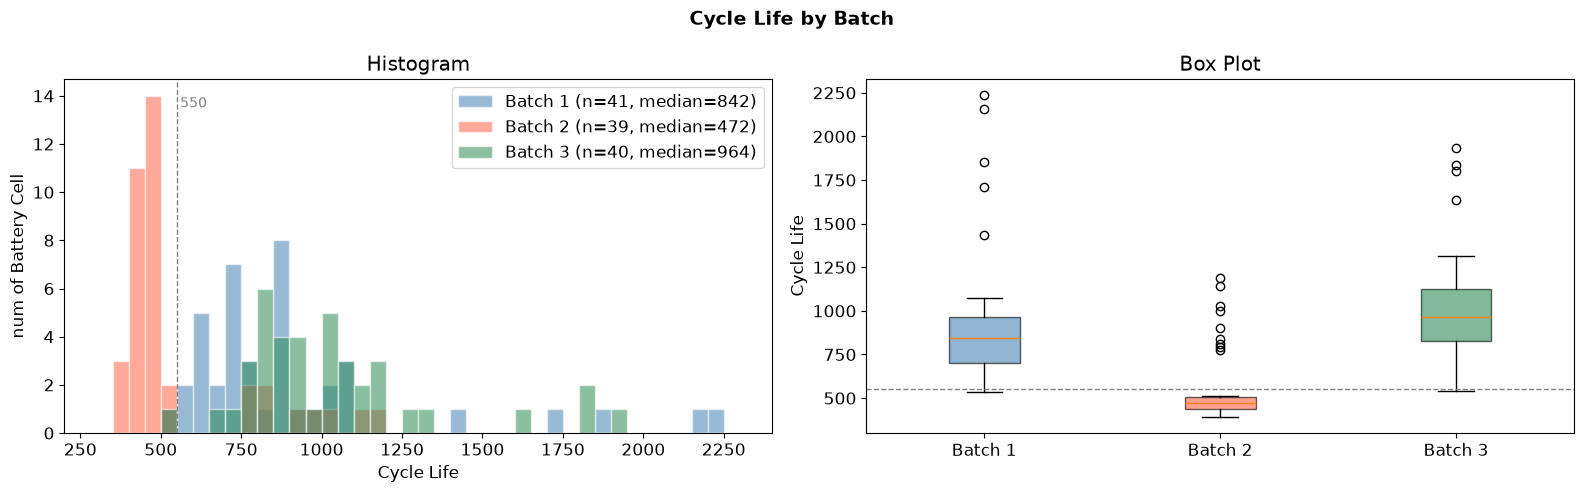

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
Batch 1,41.0,921.3,400.8,534.0,702.0,842.0,966.0,2237.0
Batch 2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
Batch 3,40.0,1032.0,308.6,541.0,827.2,964.5,1122.8,1935.0


In [34]:
# 배치별 Cycle Life 분포 비교
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bins = np.linspace(300, 2300, 41)
for name, x in cells.groupby('batch'):
    axes[0].hist(x['cycle_life'], bins=bins, color=batch_colors[name], alpha=0.55, edgecolor='white',
                 label=f"{name} (n={len(x)}, median={x['cycle_life'].median():.0f})")
axes[0].axvline(550, color='gray', linestyle='--', linewidth=1)
axes[0].text(560, axes[0].get_ylim()[1] * 0.92, '550', color='gray', fontsize=10)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].legend()

names = list(batch_colors)
bp = axes[1].boxplot([cells.loc[cells['batch'] == n, 'cycle_life'] for n in names], patch_artist=True)
for patch, n in zip(bp['boxes'], names):
    patch.set_facecolor(batch_colors[n]); patch.set_alpha(0.6)
axes[1].set_xticks(range(1, len(names) + 1)); axes[1].set_xticklabels(names)
axes[1].axhline(550, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')

plt.suptitle('Cycle Life by Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(cells.groupby('batch')['cycle_life'].describe().round(1))


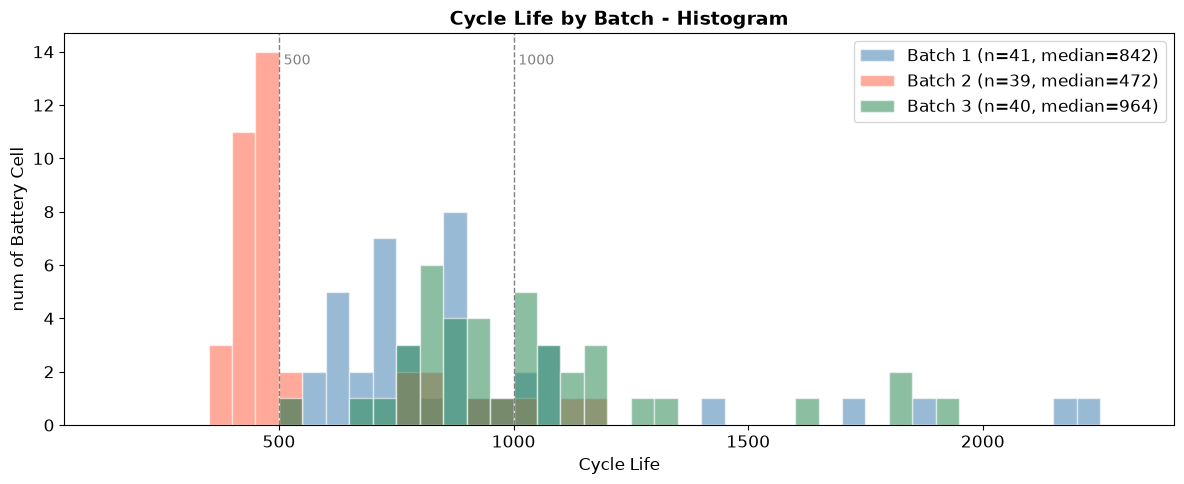

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
Batch 1,41.0,921.3,400.8,534.0,702.0,842.0,966.0,2237.0
Batch 2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
Batch 3,40.0,1032.0,308.6,541.0,827.2,964.5,1122.8,1935.0


In [39]:
# 1-1. 배치별 Cycle Life Histogram
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}

fig, ax = plt.subplots(figsize=(12, 5))
bins = np.linspace(150, 2300, 44)
for name, x in cells.groupby('batch'):
    ax.hist(x['cycle_life'], bins=bins, color=batch_colors[name], alpha=0.55, edgecolor='white',
            label=f"{name} (n={len(x)}, median={x['cycle_life'].median():.0f})")
for v in (500, 1000):
    ax.axvline(v, color='gray', linestyle='--', linewidth=1)
    ax.text(v + 10, ax.get_ylim()[1] * 0.92, str(v), color='gray', fontsize=10)
ax.set_title('Cycle Life by Batch - Histogram', fontsize=14, fontweight='bold')
ax.set_xlabel('Cycle Life')
ax.set_ylabel('num of Battery Cell')
ax.legend()
plt.tight_layout()
plt.show()

display(cells.groupby('batch')['cycle_life'].describe().round(1))


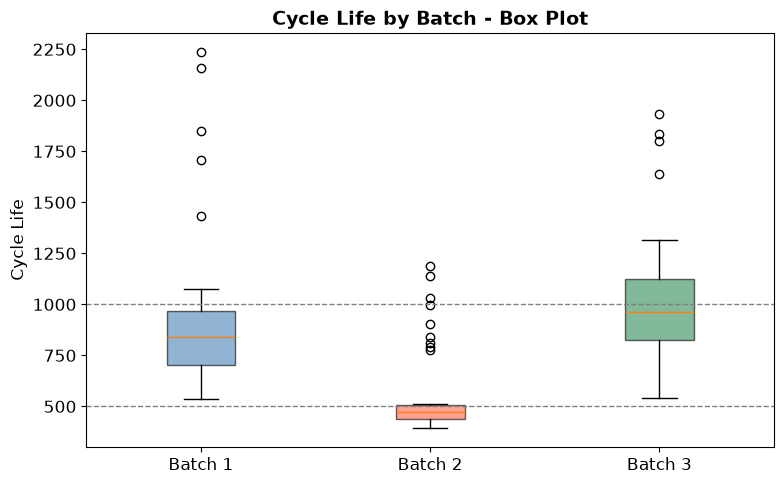

,batch,cell_id,cycle_life,charging_policy,med_chargetime
60,Batch 2,19,392,6C(60%)-3C,10.174563
47,Batch 2,6,393,3.6C(9%)-5C,10.179361
56,Batch 2,15,396,3.6C(9%)-5C,10.174974
16,Batch 1,20,534,5.4C(80%)-5.4C,9.006340
106,Batch 3,28,541,3.7C(31%)-5.9C-newstructure,10.083590
17,Batch 1,21,559,5.4C(80%)-5.4C,8.985737
40,Batch 1,45,599,8C(35%)-3.6C,10.221550
85,Batch 3,6,667,3.7C(31%)-5.9C-newstructure,10.077624
109,Batch 3,31,731,5.9C(60%)-3.1C-newstructure,10.045919


In [40]:
# 1-2. 배치별 Cycle Life Box Plot
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}
names = list(batch_colors)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([cells.loc[cells['batch'] == n, 'cycle_life'] for n in names], patch_artist=True)
for patch, n in zip(bp['boxes'], names):
    patch.set_facecolor(batch_colors[n]); patch.set_alpha(0.6)
ax.set_xticks(range(1, len(names) + 1)); ax.set_xticklabels(names)
for v in (500, 1000):
    ax.axhline(v, color='gray', linestyle='--', linewidth=1)
ax.set_title('Cycle Life by Batch - Box Plot', fontsize=14, fontweight='bold')
ax.set_ylabel('Cycle Life')
plt.tight_layout()
plt.show()

# 배치별로 가장 짧은 셀 3개
display(cells.sort_values('cycle_life').groupby('batch').head(3)[['batch', 'cell_id', 'cycle_life', 'charging_policy', 'med_chargetime']])


In [42]:
display(cells.sort_values('cycle_life').groupby('batch').head(2)[['batch', 'cell_id', 'cycle_life', 'charging_policy', 'med_chargetime']])

,batch,cell_id,cycle_life,charging_policy,med_chargetime
60,Batch 2,19,392,6C(60%)-3C,10.174563
47,Batch 2,6,393,3.6C(9%)-5C,10.179361
16,Batch 1,20,534,5.4C(80%)-5.4C,9.006340
106,Batch 3,28,541,3.7C(31%)-5.9C-newstructure,10.083590
17,Batch 1,21,559,5.4C(80%)-5.4C,8.985737
85,Batch 3,6,667,3.7C(31%)-5.9C-newstructure,10.077624


[describe] - 배치별 Cycle Life (정제 후 Batch 1 41개 / Batch 2 39개 / Batch 3 40개 셀)
- 중앙값 : Batch 1 842 / Batch 2 472 / Batch 3 964.5
- 범위 : Batch 1 534 ~ 2237 / Batch 2 392 ~ 1186 / Batch 3 541 ~ 1935
- IQR : Batch 1 702 ~ 966 / Batch 2 440 ~ 509 / Batch 3 827 ~ 1123
- 장수명(>1,000) 비율 : 24% / 8% / 48%
- 단수명(<500) 비율 : 0% / 72% / 0%

[plot]
- Histogram : Batch 2만 550 사이클 왼쪽에 몰려 있고 Batch 1·3과 거의 겹치지 않음
    - Batch 1·3은 600 ~ 1200 구간에 모여 있고 오른쪽으로 긴 꼬리를 가짐
- Box plot 
    - Batch 2 : 상자가 매우 좁고(440 ~ 509), 그 위로 9개 셀(777 ~ 1186)이 이상치로 따로 찍힘 -> 두 봉우리 분포
        - 이 9개는 모두 정책명에 `newstructure`가 붙은 셀. 원논문에 설명이 없어 의미는 확인하지 못함
    - Batch 1 : 상자 702 ~ 966, 위쪽 이상치 5개(1434 ~ 2237). 가장 느린 충전 정책의 셀
    - Batch 3 : 상자 827 ~ 1123으로 Batch 1보다 전체적으로 높음, 위쪽 이상치 4개(1638 ~ 1935)
- 유독 짧은 셀 
    - Batch 2의 최단 셀(392, 393, 396)은 `6C(60%)-3C`, `3.6C(9%)-5C` 정책
    - Batch 3의 최단 셀(541)은 `3.7C(31%)-5.9C` 정책
    - 같은 정책이어도 배치에 따라 수명이 다름 : `6C(60%)-3C`는 Batch 1에서 731, 757 / Batch 2에서 392, 408

[to modeling]
- 학습(Batch 1)과 테스트(Batch 2)의 target 분포가 다름 : Batch 2 셀의 77%(30개)가 Batch 1의 최솟값(534)보다 짧음 -> 학습 범위 밖을 예측해야 함
    - Regression : 학습에 없던 짧은 수명 구간으로 외삽해야 하므로 Batch 2 오차가 커질 위험. 트리 계열 모델은 학습 범위 밖의 값을 예측하지 못하므로 선형 계열이 유리
    - Classification(550 기준) : Batch 1에 550 미만 셀이 1개뿐이라 단수명 클래스를 학습하기 어려움
- 세 배치 모두 오른쪽 꼬리가 길어 target 로그 변환 검토
- Batch 3는 Batch 1과 분포가 비슷해 Batch 2보다 예측이 쉬울 가능성이 있음 -> 추가 테스트 시 Batch 2와의 성능 차이를 분포 차이로 해석

2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?

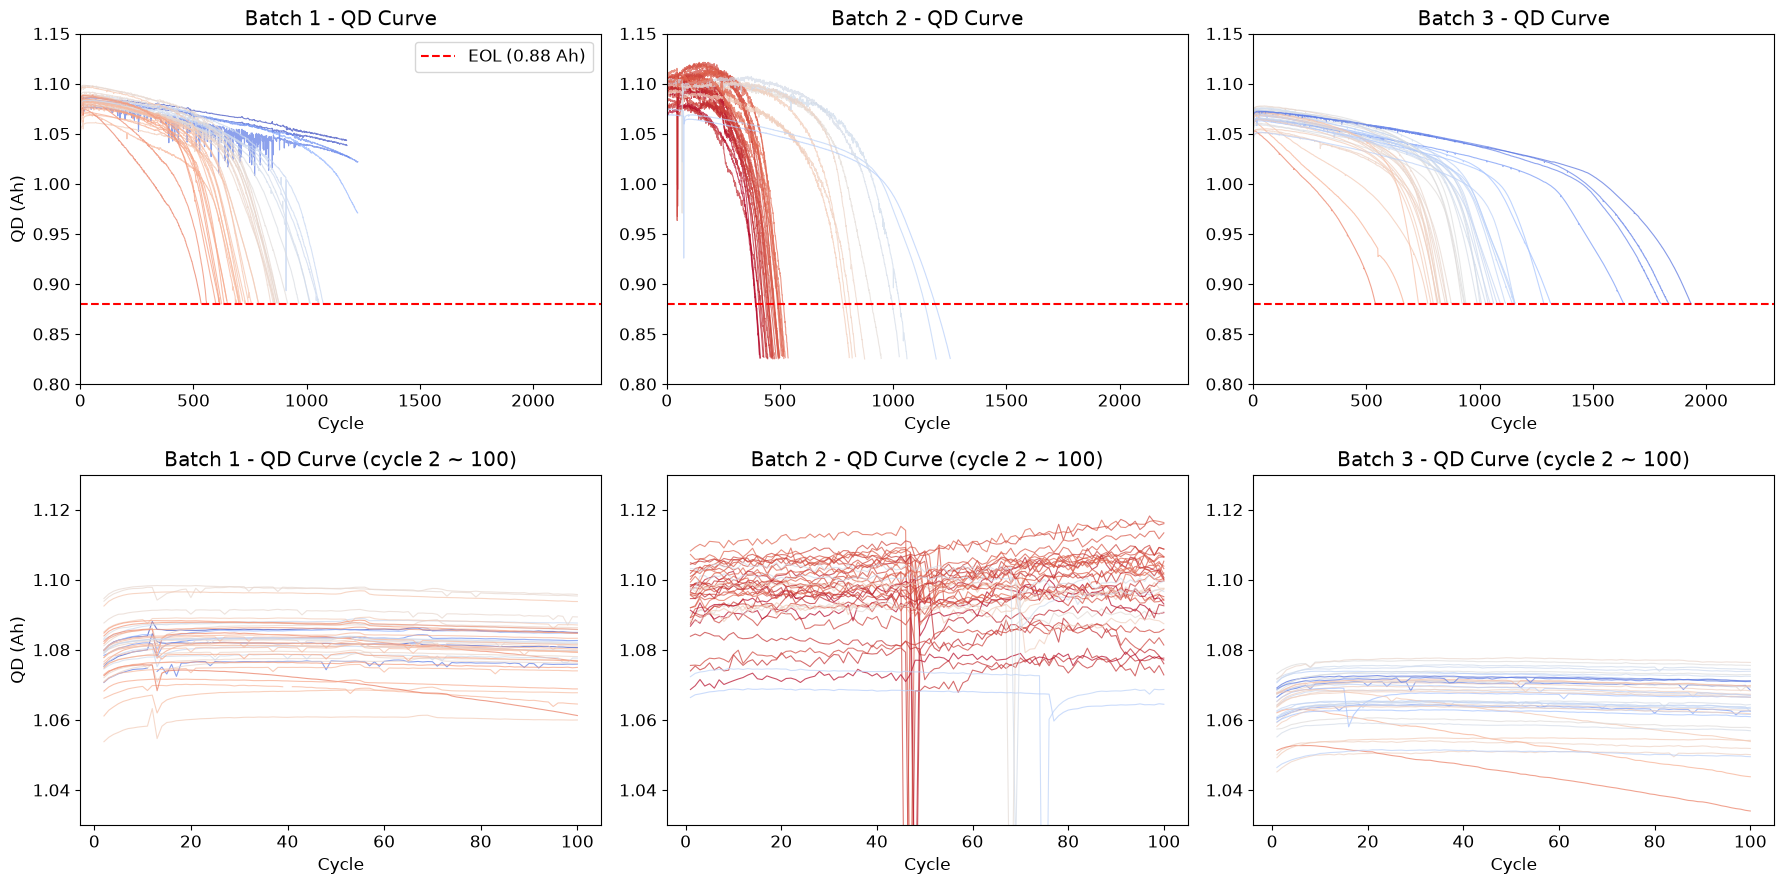

batch,Batch 1,Batch 2,Batch 3
EOL 도달 셀 수,36.00,39.00,40.00
QD_2,1.08,1.10,1.07
QD_100,1.08,1.10,1.07
전반부 50% 감소 비중,0.08,0.03,0.10
마지막 100사이클 감소 비중,0.48,0.71,0.50
knee 시점 (수명 대비),0.83,0.85,0.82
knee -> EOL (사이클),135.00,76.00,163.00
cycle100 > cycle2 인 셀 비율,0.90,0.64,0.85


In [35]:
# 배치별 열화 곡선 비교 (색 = cycle life, 파랑: 장수 / 빨강: 단명)
norm = LogNorm(cells['cycle_life'].min(), cells['cycle_life'].max())
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for j, (name, d) in enumerate(summ.items()):
    for cid, x in d.groupby('cell_id'):
        color = cm.coolwarm_r(norm(x['cycle_life'].iloc[0]))
        axes[0, j].plot(x['cycle'], x['QD'], color=color, linewidth=0.8, alpha=0.7)
        e = x[x['cycle'] <= 100]
        axes[1, j].plot(e['cycle'], e['QD'], color=color, linewidth=0.8, alpha=0.7)
    axes[0, j].axhline(0.88, color='red', linestyle='--', linewidth=1.5, label='EOL (0.88 Ah)')
    axes[0, j].set_title(f'{name} - QD Curve')
    axes[0, j].set_xlabel('Cycle'); axes[0, j].set_xlim(0, 2300); axes[0, j].set_ylim(0.8, 1.15)
    axes[1, j].set_title(f'{name} - QD Curve (cycle 2 ~ 100)')
    axes[1, j].set_xlabel('Cycle'); axes[1, j].set_ylim(1.03, 1.13)
axes[0, 0].set_ylabel('QD (Ah)'); axes[1, 0].set_ylabel('QD (Ah)'); axes[0, 0].legend()
plt.tight_layout()
plt.show()

# 배치별 열화 패턴 요약 (EOL에 도달한 셀 기준, knee = 용량이 처음 1.0Ah 아래로 내려간 사이클)
rows = []
for name, d in summ.items():
    for cid, x in d.groupby('cell_id'):
        life = x['cycle_life'].iloc[0]
        q = x[x['cycle'] <= life].dropna(subset=['QD']).set_index('cycle')['QD']
        r = {'batch': name, 'QD_2': q[2], 'QD_100': q[100]}
        if q.iloc[-1] < 0.89:                       # EOL(0.88Ah)까지 측정된 셀만
            total = q[2] - q.iloc[-1]
            knee  = q[q < 1.0].index[0]
            r.update({'전반부 50% 감소 비중': (q[2] - q[q.index <= life / 2].iloc[-1]) / total,
                      '마지막 100사이클 감소 비중': (q[q.index <= life - 100].iloc[-1] - q.iloc[-1]) / total,
                      'knee 시점 (수명 대비)': knee / life, 'knee -> EOL (사이클)': life - knee})
        rows.append(r)
deg = pd.DataFrame(rows)
tbl = deg.groupby('batch').median().round(2)
tbl.insert(0, 'EOL 도달 셀 수', deg.dropna().groupby('batch').size())
tbl['cycle100 > cycle2 인 셀 비율'] = deg.assign(up=deg['QD_100'] > deg['QD_2']).groupby('batch')['up'].mean().round(2)
display(tbl.T)


[plot] - 색 = cycle life (파랑 : 장수 / 빨강 : 단명, 로그 스케일, 세 배치 공통 기준)
- 전체 곡선 (위) : "평탄 구간 뒤 급락"이라는 형태는 세 배치 공통
    - Batch 1 : 500 ~ 1100 사이클에 EOL 도달. 장수 셀 5개는 약 1200 사이클에서 곡선이 끊김 (이후 구간 데이터 없음)
    - Batch 2 : 대부분의 셀이 400 ~ 500 사이클에 몰려서 급락. `newstructure` 9개 셀만 800 ~ 1200 사이클까지 유지. 0.88 Ah 이후 약 0.83 Ah까지 측정이 이어짐
    - Batch 3 : 500 ~ 1900 사이클에 고르게 퍼져 있고 곡선이 가장 매끄러움
- 초기 100 사이클 (아래) : 세 배치 모두 색이 뒤섞여 있어 수명을 구분할 수 없음
    - 용량 수준이 배치마다 다름 : cycle 2 중앙값 Batch 1 1.08 / Batch 2 1.10 / Batch 3 1.07 Ah
    - Batch 2는 사이클 간 변동이 큼 : 셀별 용량 표준편차(중앙값)가 0.003 Ah로 Batch 1·3(약 0.001 Ah)의 3배. cycle 47 ~ 50 부근에서 여러 셀이 동시에 급락했다가 회복
    - Batch 1·3은 cycle 100 용량이 cycle 2보다 높은 셀이 90%, 85% / Batch 2는 64%
- 열화 속도 : 세 배치 모두 일정하지 않고 말기에 가속
    - 수명 전반부 50%의 감소 비중 : 8% / 3% / 10%
    - 마지막 100 사이클의 감소 비중 : 48% / 71% / 50%
- Knee point (용량이 처음 1.0 Ah 아래로 내려간 사이클로 정의)
    - 발생 시점은 세 배치 모두 수명의 82 ~ 85% 지점으로 거의 같음
    - knee에서 EOL까지 : 135 / 76 / 163 사이클 -> Batch 2가 가장 가파르게 떨어짐

[to modeling]
- 초기 100 사이클의 용량 수준은 세 배치 어디에서도 수명을 구분하지 못함 -> QD 값 자체는 주 피처로 부적합, ΔQ(V) 필요
- 용량의 절대 수준이 배치마다 다름(1.07 ~ 1.10 Ah) -> 용량 절댓값을 피처로 쓰면 배치 차이가 그대로 들어감. 차이나 비율처럼 셀 자신의 기준값 대비 변화로 만든 피처가 유리
- Batch 2는 초기 구간에 변동과 동시 급락이 있음 -> 단일 사이클 값(예 : cycle 100 하나)에 의존하는 피처는 테스트에서 불안정할 수 있음. 구간 통계나 평활화 검토
- knee 시점이 수명의 일정 비율(약 83%)에서 나타난다는 점은 세 배치 공통 -> 수명 차이는 knee가 언제 시작되느냐의 문제이며, 초기 100 사이클에는 아직 나타나지 않음

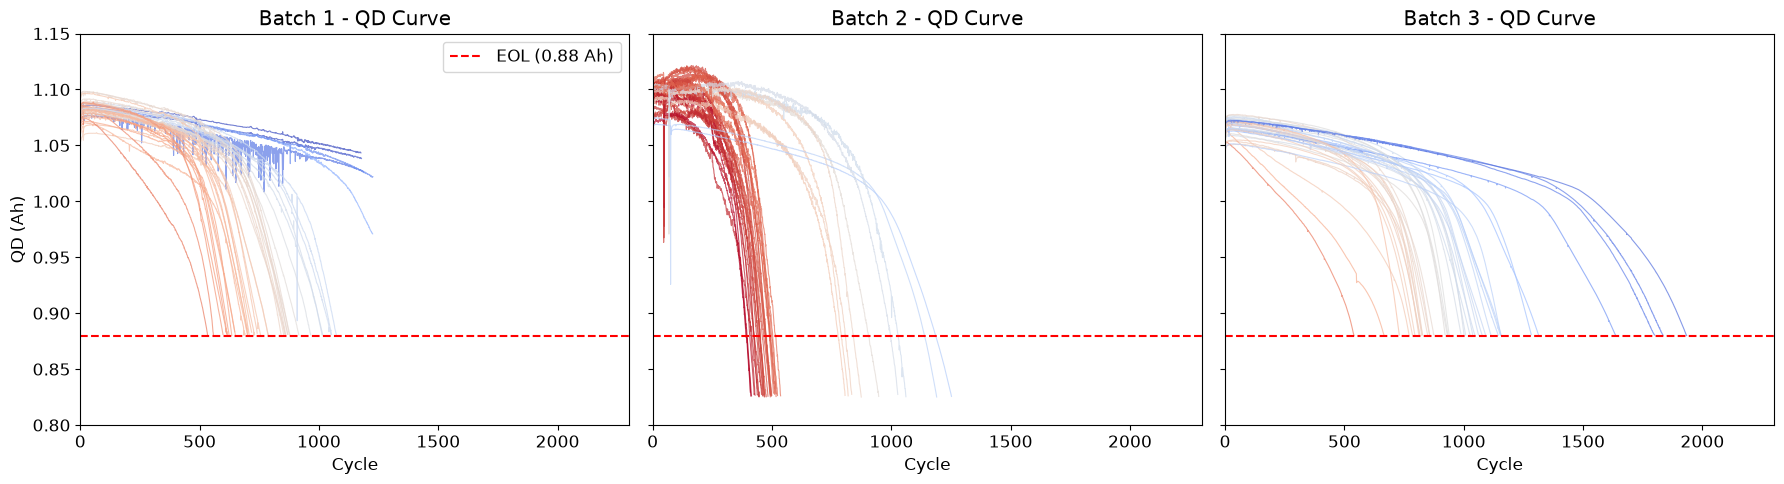

In [43]:
# 2-1. 사이클별 방전 용량(Qd) 추이 (색 = cycle life, 파랑: 장수 / 빨강: 단명)
norm = LogNorm(cells['cycle_life'].min(), cells['cycle_life'].max())
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, d) in zip(axes, summ.items()):
    for cid, x in d.groupby('cell_id'):
        ax.plot(x['cycle'], x['QD'], color=cm.coolwarm_r(norm(x['cycle_life'].iloc[0])), linewidth=0.8, alpha=0.7)
    ax.axhline(0.88, color='red', linestyle='--', linewidth=1.5, label='EOL (0.88 Ah)')
    ax.set_title(f'{name} - QD Curve')
    ax.set_xlabel('Cycle'); ax.set_xlim(0, 2300); ax.set_ylim(0.8, 1.15)
axes[0].set_ylabel('QD (Ah)'); axes[0].legend()
plt.tight_layout()
plt.show()


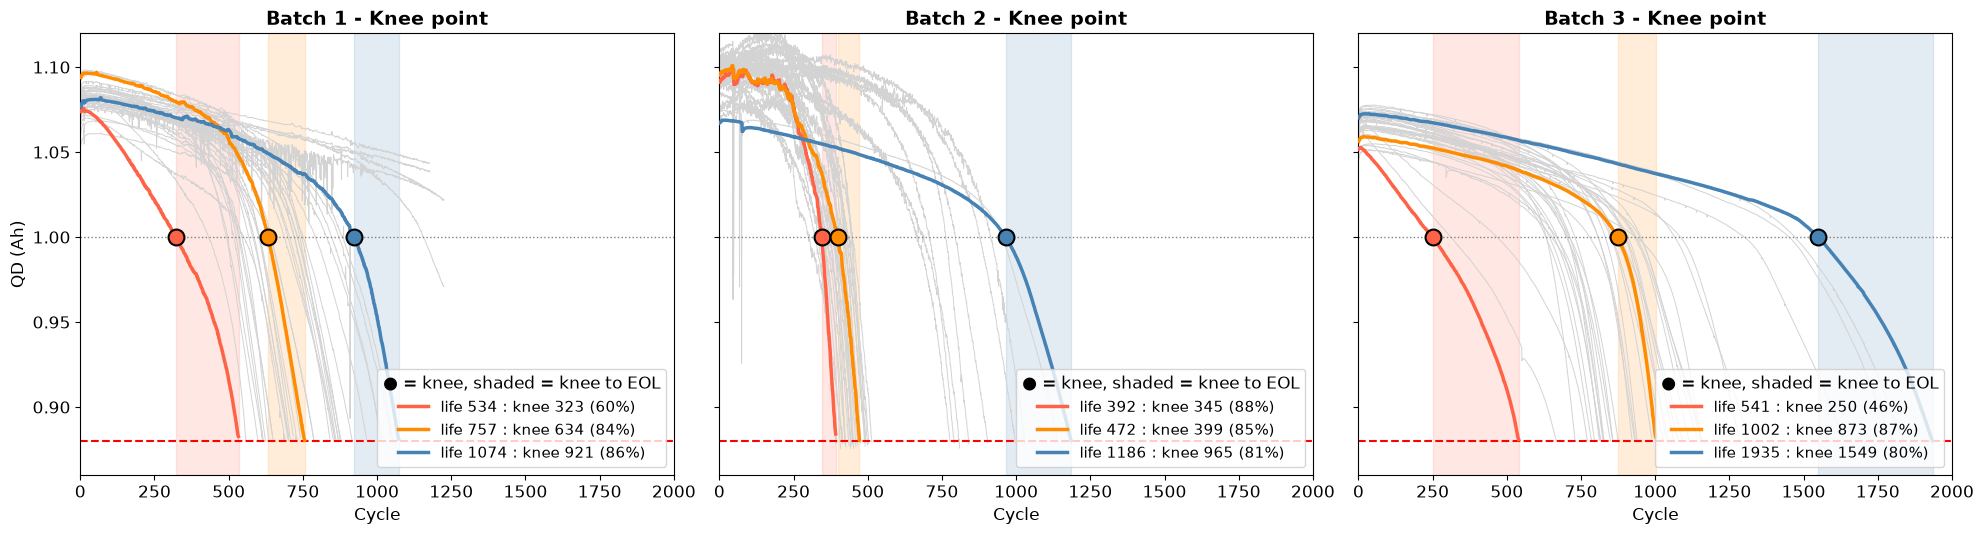

In [45]:
# 2-3. Knee point : 배치별 대표 셀 3개 (수명 최단 / 중간 / 최장)의 열화 곡선과 knee
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=True)
line_colors = ['tomato', 'darkorange', 'steelblue']
for ax, (name, d) in zip(axes, summ.items()):
    curves = {}
    for cid, x in d.groupby('cell_id'):
        life = x['cycle_life'].iloc[0]
        q = x[x['cycle'] <= life].dropna(subset=['QD']).set_index('cycle')['QD']
        ax.plot(q.index, q.values, color='lightgray', linewidth=0.7, zorder=1)      # 전체 셀은 배경으로
        if q.iloc[-1] < 0.89:
            curves[life] = q
    lives = sorted(curves)
    for life, color in zip([lives[0], lives[len(lives) // 2], lives[-1]], line_colors):
        q = curves[life]
        k = q[q >= 1.0].index[-1] + 1                                              # knee point
        ax.plot(q.index, q.rolling(5, center=True, min_periods=1).median(), color=color, linewidth=2.5, zorder=3,
                label=f'life {life} : knee {k} ({k / life:.0%})')
        ax.axvspan(k, life, color=color, alpha=0.15, zorder=0)                     # knee ~ EOL 구간
        ax.scatter(k, 1.0, color=color, s=130, edgecolors='black', linewidths=1.5, zorder=4)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1)
    ax.axhline(0.88, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name} - Knee point', fontsize=14, fontweight='bold')
    ax.set_xlabel('Cycle'); ax.set_xlim(0, 2000); ax.set_ylim(0.86, 1.12)
    ax.legend(loc='lower right', fontsize=11, title='● = knee, shaded = knee to EOL')
axes[0].set_ylabel('QD (Ah)')
plt.tight_layout()
plt.show()


3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?

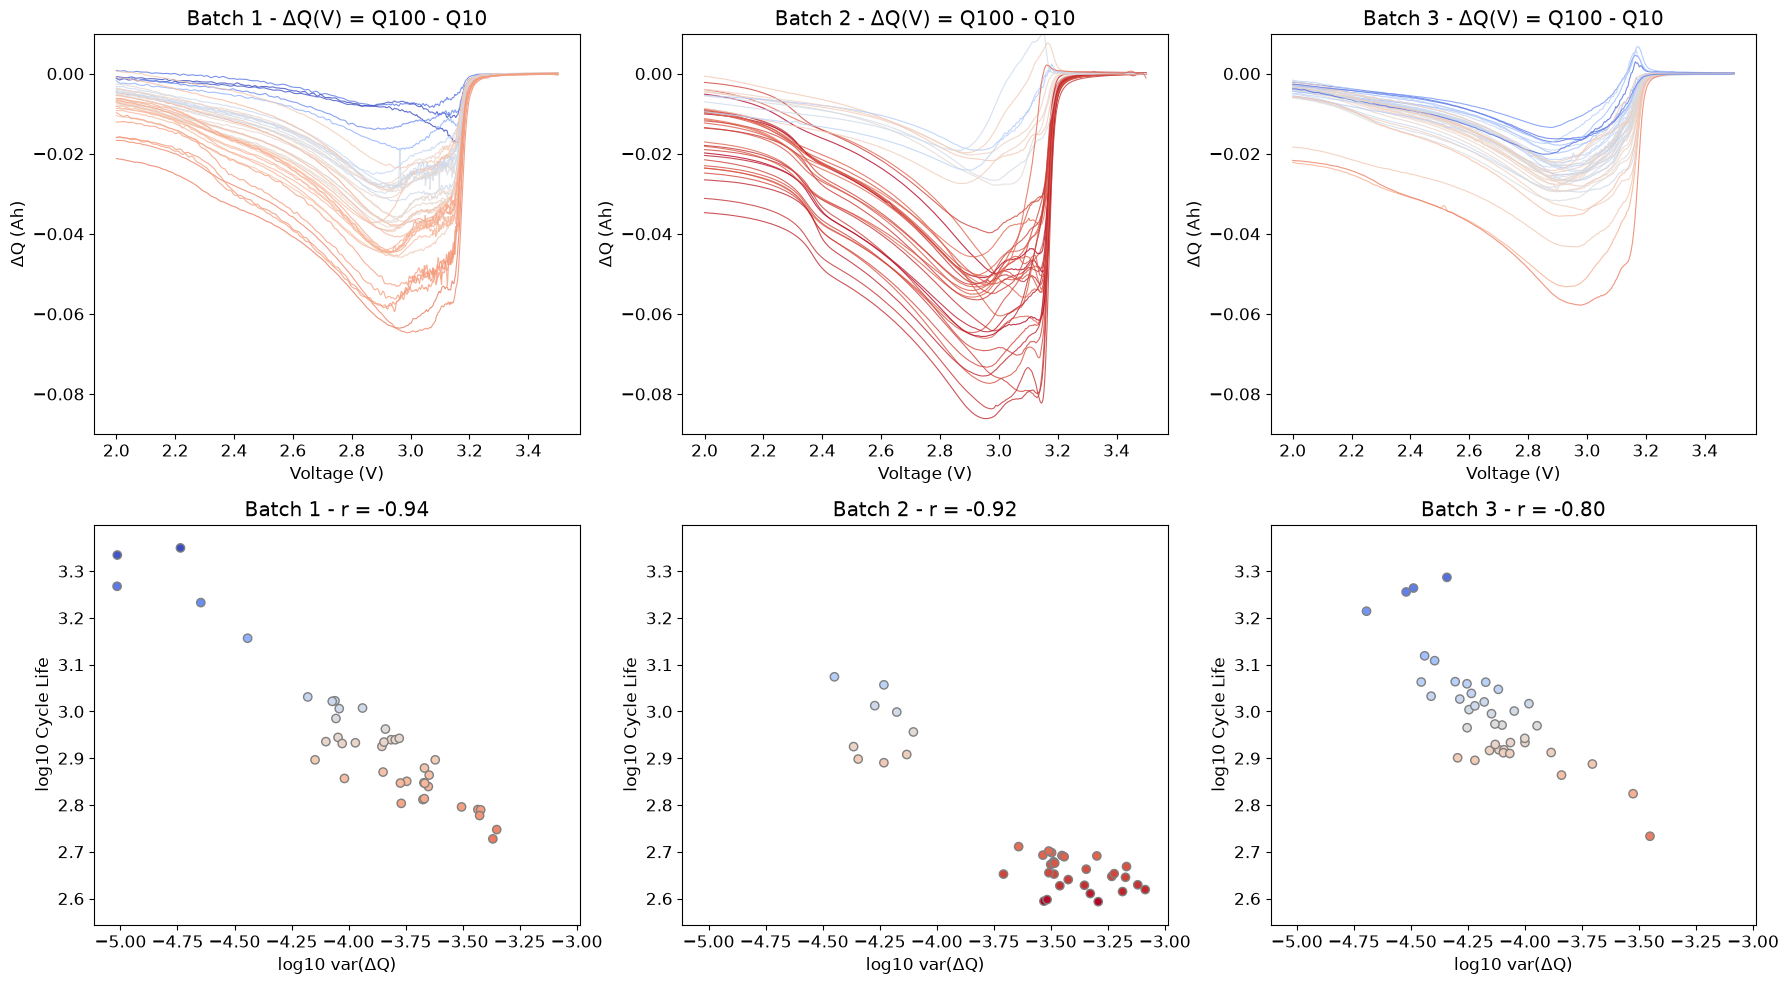

ΔQ(V) 통계값과 log10(cycle_life)의 상관계수


,Batch 1,Batch 2,Batch 3,전체
log_dQ_var,-0.94,-0.92,-0.80,-0.92
dQ_min,0.87,0.84,0.75,0.87
dQ_mean,0.85,0.79,0.69,0.84


In [36]:
# 3. ΔQ(V) = Q100(V) - Q10(V) 곡선과 수명의 관계 (색 = cycle life, 파랑: 장수 / 빨강: 단명)
norm = LogNorm(cells['cycle_life'].min(), cells['cycle_life'].max())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for j, (name, x) in enumerate(cells.groupby('batch')):
    for _, r in x.iterrows():
        axes[0, j].plot(Vdlin, DQ[name][r['cell_id']], color=cm.coolwarm_r(norm(r['cycle_life'])), linewidth=0.8, alpha=0.8)
    axes[0, j].set_title(f'{name} - ΔQ(V) = Q100 - Q10')
    axes[0, j].set_xlabel('Voltage (V)'); axes[0, j].set_ylabel('ΔQ (Ah)'); axes[0, j].set_ylim(-0.09, 0.01)
    axes[1, j].scatter(x['log_dQ_var'], x['log_life'], c=x['cycle_life'], cmap='coolwarm_r', norm=norm, edgecolors='gray')
    axes[1, j].set_title(f"{name} - r = {x['log_dQ_var'].corr(x['log_life']):.2f}")
    axes[1, j].set_xlabel('log10 var(ΔQ)'); axes[1, j].set_ylabel('log10 Cycle Life')
    axes[1, j].set_xlim(cells['log_dQ_var'].min() - 0.1, cells['log_dQ_var'].max() + 0.1)
    axes[1, j].set_ylim(cells['log_life'].min() - 0.05, cells['log_life'].max() + 0.05)
plt.tight_layout()
plt.show()

dq_feats = ['log_dQ_var', 'dQ_min', 'dQ_mean']
dq_corr = pd.DataFrame({name: x[dq_feats].corrwith(x['log_life']) for name, x in cells.groupby('batch')})
dq_corr['전체'] = cells[dq_feats].corrwith(cells['log_life'])
print("ΔQ(V) 통계값과 log10(cycle_life)의 상관계수")
display(dq_corr.round(2))


[plot] - ΔQ(V) = Q100(V) - Q10(V) : cycle 100과 cycle 10의 방전 용량-전압 곡선 차이 (1,000 포인트)
- 곡선 (위) : 초기 100 사이클만으로 장·단수명 셀이 구분됨
    - 단수명 셀(빨강)일수록 곡선이 아래로 깊게 내려가고, 장수명 셀(파랑)은 0 근처에 머묾
    - 용량 값(QD)에서는 보이지 않던 차이가 전압 곡선의 변화에서는 드러남
    - Batch 2는 곡선이 가장 깊고(최솟값 중앙값 -0.054 Ah), Batch 3는 가장 얕음(-0.025 Ah) -> 수명 분포의 차이와 같은 방향
- 통계값 (아래) : log10(ΔQ 분산)과 log10(cycle life)가 직선에 가까운 관계
    - 상관계수 : Batch 1 -0.94 / Batch 2 -0.92 / Batch 3 -0.80 (원논문 -0.93)
    - 최솟값 0.87 / 0.84 / 0.75, 평균 0.85 / 0.79 / 0.69 -> 분산이 가장 강함
- 배치 간 비교 : 세 배치 모두 같은 방향의 강한 관계
    - Batch 2의 -0.92는 `newstructure` 9개 셀과 나머지 30개를 구분하는 효과가 대부분. 수명 392 ~ 514인 30개 셀 안에서는 -0.38 -> 수명 범위가 좁은 구간에서는 변별력이 떨어짐
    - Batch 3는 -0.80으로 다소 약함

[to modeling]
- ΔQ(V)의 분산을 핵심 피처로 사용. target과 분산 모두 로그 변환 (로그-로그에서 선형 관계)
- 최솟값·평균은 분산과 거의 같은 정보(Batch 1에서 서로 0.93 ~ 0.99 상관) -> 함께 넣으면 다중공선성. 하나만 쓰거나 규제 모델 사용
- 이 정의(cycle 100 - cycle 10)는 Regression용. Classification(초기 5 사이클)에는 쓸 수 없음


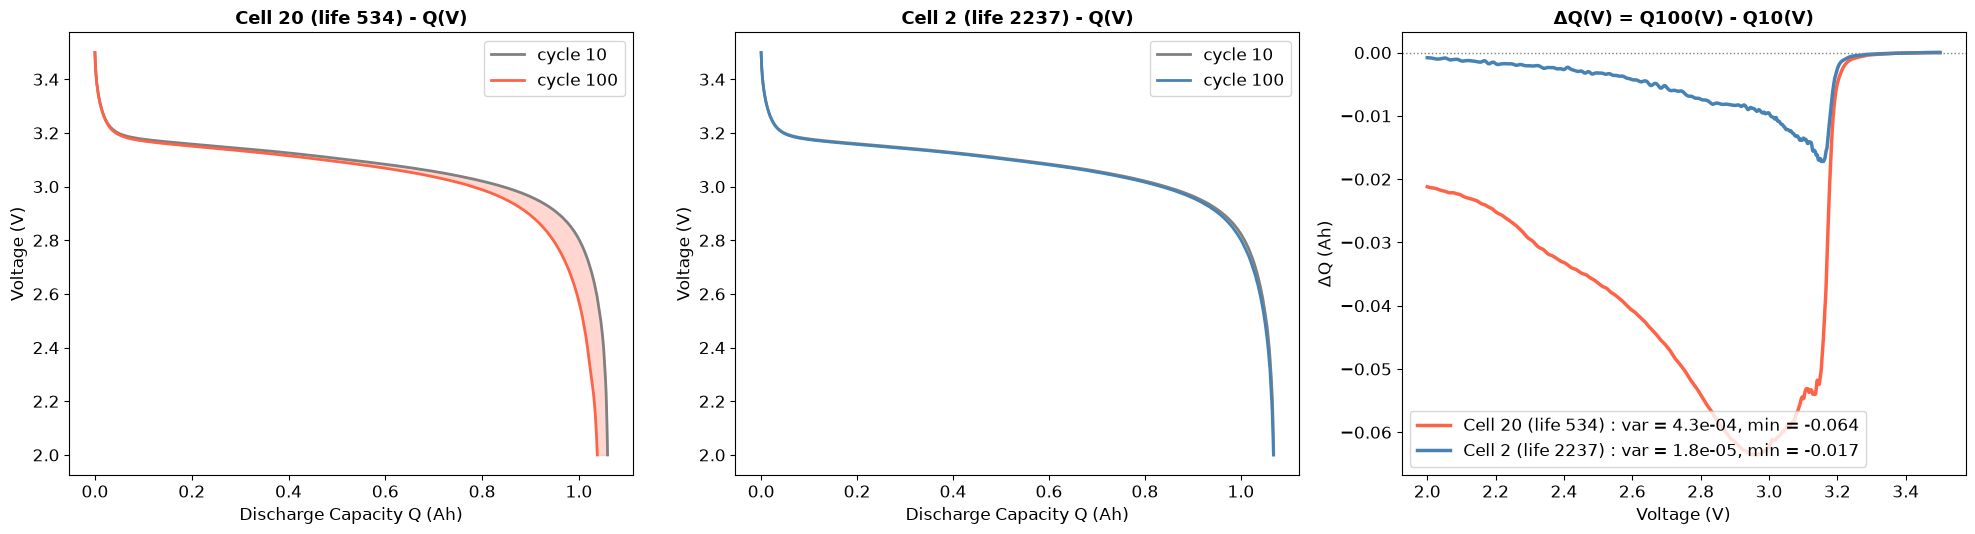

Vdlin : 1000개 포인트, 3.5V -> 2.0V


In [46]:
# 3-1. ΔQ(V) 계산 과정 : Batch 1의 단수명 셀(20)과 장수명 셀(2) 예시
def read_qdlin(name, cell_id, cycle):
    f = h5py.File(os.path.join(DATA_DIR, BATCH_FILES[name]), 'r')
    c = f[f['batch']['cycles'][cell_id, 0]]
    return np.array(f[c['Qdlin'][cycle - 1, 0]]).ravel()

examples = [('Batch 1', 20, 'tomato'), ('Batch 1', 2, 'steelblue')]
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, (name, cid, color) in zip(axes[:2], examples):
    life = cells.loc[(cells['batch'] == name) & (cells['cell_id'] == cid), 'cycle_life'].iloc[0]
    q10, q100 = read_qdlin(name, cid, 10), read_qdlin(name, cid, 100)
    ax.plot(q10, Vdlin, color='gray', linewidth=2, label='cycle 10')
    ax.plot(q100, Vdlin, color=color, linewidth=2, label='cycle 100')
    ax.fill_betweenx(Vdlin, q10, q100, color=color, alpha=0.25)
    ax.set_title(f'Cell {cid} (life {life}) - Q(V)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Discharge Capacity Q (Ah)'); ax.set_ylabel('Voltage (V)'); ax.legend()
    axes[2].plot(Vdlin, q100 - q10, color=color, linewidth=2.5,
                 label=f'Cell {cid} (life {life}) : var = {np.var(q100 - q10):.1e}, min = {(q100 - q10).min():.3f}')
axes[2].axhline(0, color='gray', linestyle=':', linewidth=1)
axes[2].set_title('ΔQ(V) = Q100(V) - Q10(V)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Voltage (V)'); axes[2].set_ylabel('ΔQ (Ah)'); axes[2].legend(loc='lower left')
plt.tight_layout()
plt.show()

print(f"Vdlin : {len(Vdlin)}개 포인트, {Vdlin.max():.1f}V -> {Vdlin.min():.1f}V")


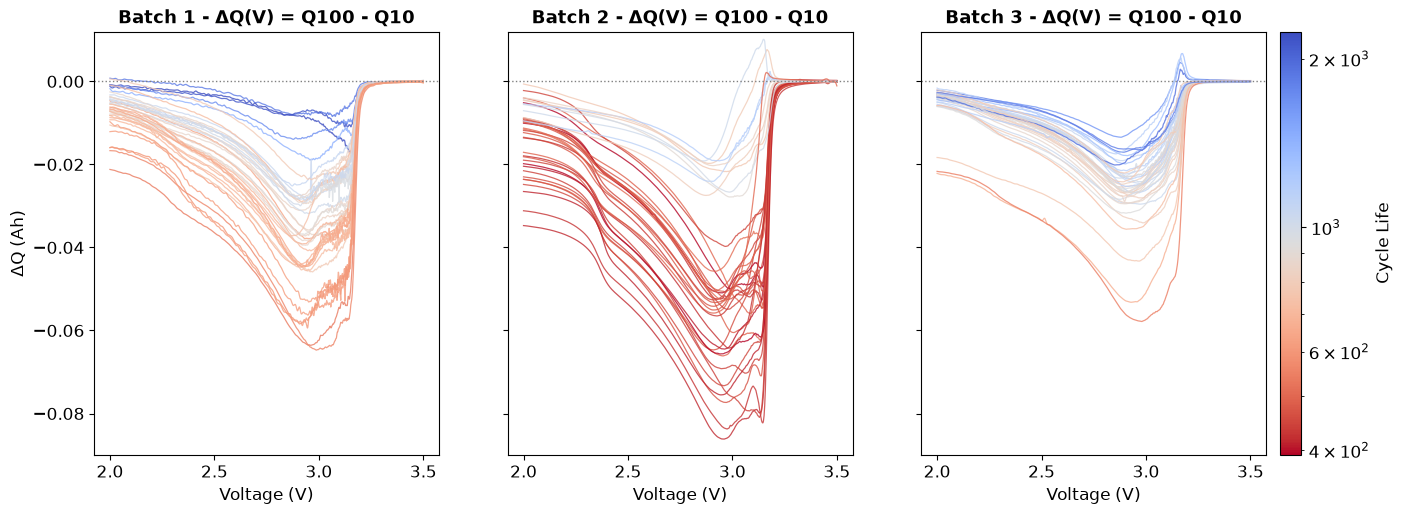

In [47]:
# 3-2. 배치별 ΔQ(V) 곡선 (색 = cycle life, 파랑: 장수 / 빨강: 단명)
norm = LogNorm(cells['cycle_life'].min(), cells['cycle_life'].max())
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, (name, x) in zip(axes, cells.groupby('batch')):
    for _, r in x.iterrows():
        ax.plot(Vdlin, DQ[name][r['cell_id']], color=cm.coolwarm_r(norm(r['cycle_life'])), linewidth=0.9, alpha=0.8)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{name} - ΔQ(V) = Q100 - Q10', fontsize=13, fontweight='bold')
    ax.set_xlabel('Voltage (V)'); ax.set_ylim(-0.09, 0.012)
axes[0].set_ylabel('ΔQ (Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='coolwarm_r'), ax=axes, label='Cycle Life', pad=0.01)
plt.show()


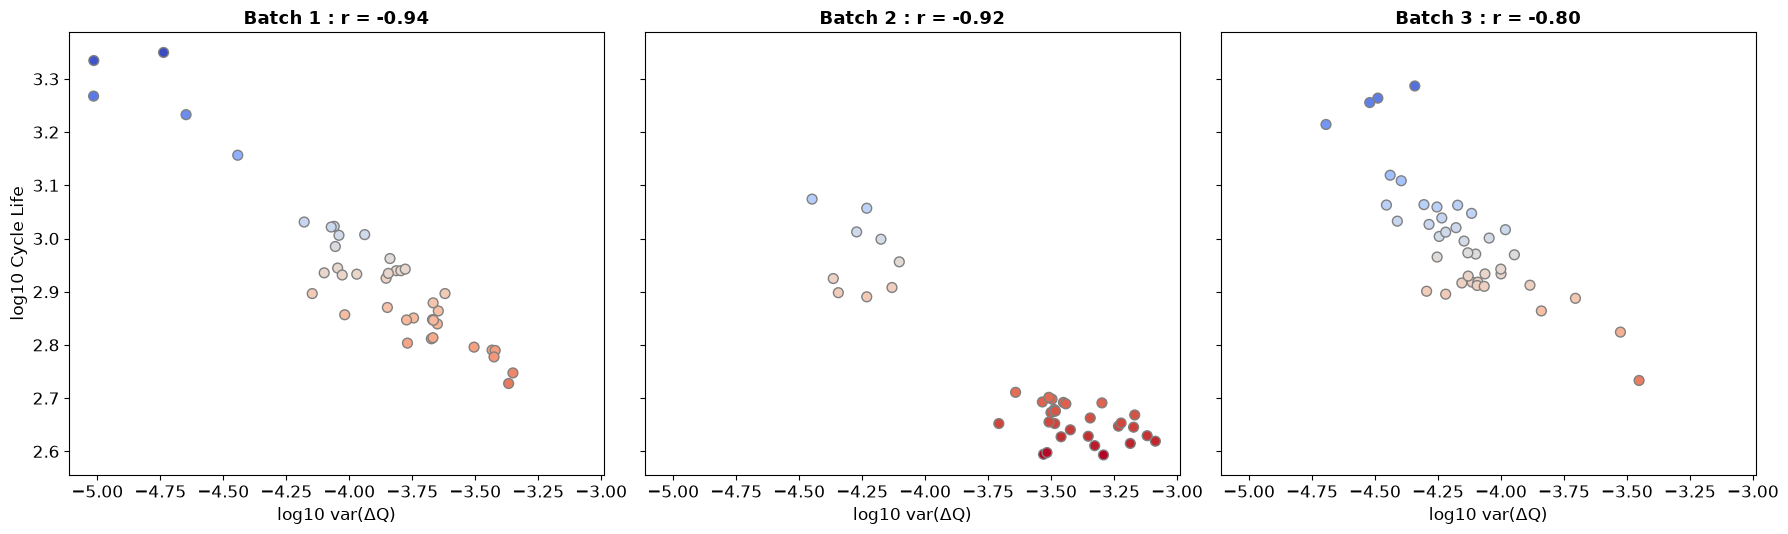

,Batch 1,Batch 2,Batch 3,전체
log_dQ_var,-0.94,-0.92,-0.80,-0.92
dQ_min,0.87,0.84,0.75,0.87
dQ_mean,0.85,0.79,0.69,0.84


In [48]:
# 3-3. ΔQ(V) 분산과 수명의 관계 (로그-로그)
norm = LogNorm(cells['cycle_life'].min(), cells['cycle_life'].max())
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)
for ax, (name, x) in zip(axes, cells.groupby('batch')):
    ax.scatter(x['log_dQ_var'], x['log_life'], c=x['cycle_life'], cmap='coolwarm_r', norm=norm, s=50, edgecolors='gray')
    ax.set_title(f"{name} : r = {x['log_dQ_var'].corr(x['log_life']):.2f}", fontsize=13, fontweight='bold')
    ax.set_xlabel('log10 var(ΔQ)')
axes[0].set_ylabel('log10 Cycle Life')
plt.tight_layout()
plt.show()

dq_feats = ['log_dQ_var', 'dQ_min', 'dQ_mean']
dq_corr = pd.DataFrame({name: x[dq_feats].corrwith(x['log_life']) for name, x in cells.groupby('batch')})
dq_corr['전체'] = cells[dq_feats].corrwith(cells['log_life'])
display(dq_corr.round(2))


4. 충전 조건 (C-rate)과 수명의 관계는?

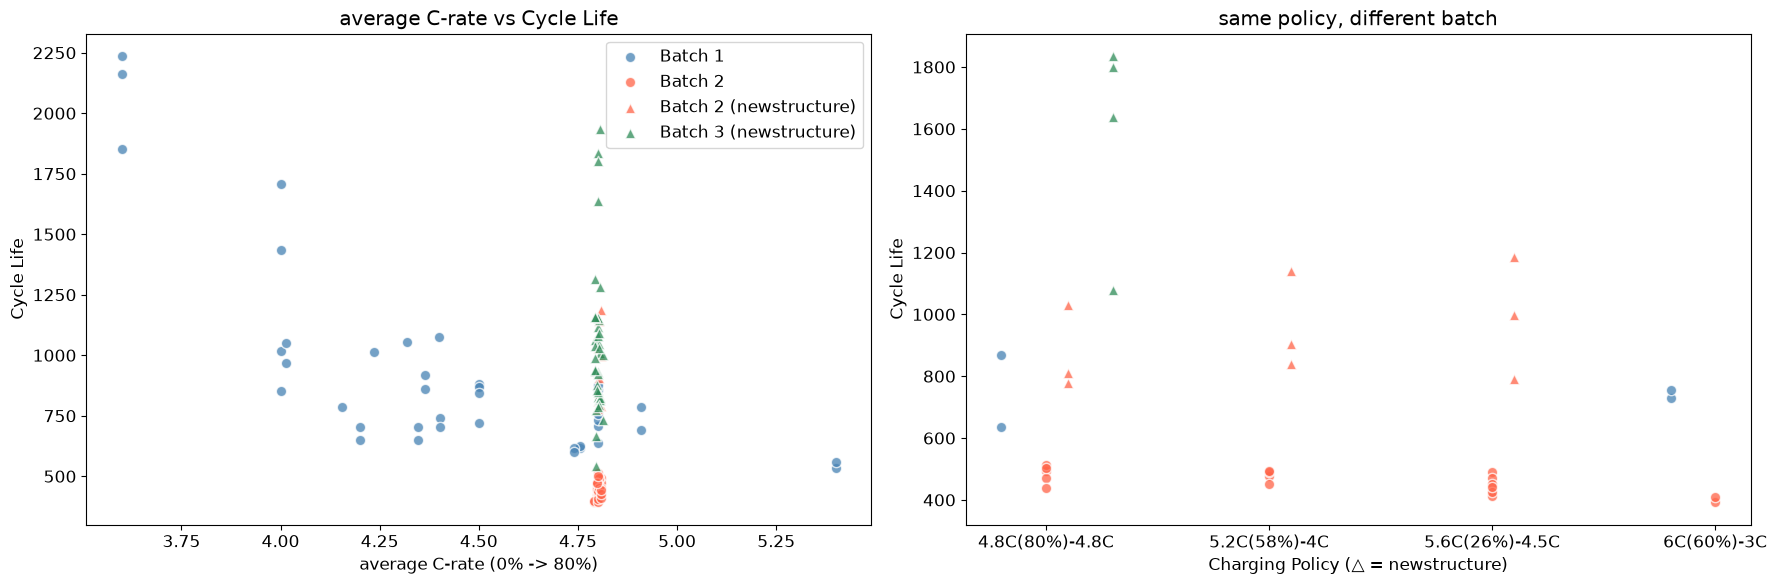

batch,Batch 1,Batch 2,Batch 3
정책 수,22,12,8
Batch 1과 겹치는 정책 수,22,2,0
newstructure 셀 수,0,9,40
평균 충전 속도 범위,3.6 ~ 5.4C,4.8 ~ 4.8C,4.8 ~ 4.8C
"상관(평균 충전 속도, 수명)",-0.74,0.33,-0.02
"상관(충전 시간, 수명)",0.79,-0.92,0.6


count   min   max    mean
base_policy    batch   newstructure                           
4.8C(80%)-4.8C Batch 1 False             2   636   870   753.0
               Batch 2 False             5   437   514   484.0
                       True              3   777  1029   872.0
               Batch 3 True              4  1078  1836  1588.0
5.2C(58%)-4C   Batch 2 False             4   452   493   478.0
                       True              3   841  1140   962.0
5.6C(26%)-4.5C Batch 2 False             6   412   491   448.0
                       True              3   791  1186   991.0
6C(60%)-3C     Batch 1 False             2   731   757   744.0
               Batch 2 False             2   392   408   400.0

In [37]:
# 4. 충전 조건과 수명 : 정책명 -> 수치 변환 후 배치 비교
pol = cells['charging_policy'].str.extract(r'([\d.]+)C\((\d+)%\)-([\d.]+)C').astype(float)
cells['C1'], cells['Q1'], cells['C2'] = pol[0], pol[1], pol[2]
cells['avg_C'] = 80 / (cells['Q1'] / cells['C1'] + (80 - cells['Q1']) / cells['C2'])   # 0% -> 80% 평균 충전 속도
cells['newstructure'] = cells['charging_policy'].str.contains('newstructure')
cells['base_policy'] = cells['charging_policy'].str.replace('-newstructure', '')

batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (왼쪽) 평균 충전 속도 vs 수명
for (name, ns), x in cells.groupby(['batch', 'newstructure']):
    axes[0].scatter(x['avg_C'], x['cycle_life'], color=batch_colors[name], marker='^' if ns else 'o',
                    s=55, alpha=0.75, edgecolors='white', label=f"{name}{' (newstructure)' if ns else ''}")
axes[0].set_xlabel('average C-rate (0% -> 80%)'); axes[0].set_ylabel('Cycle Life')
axes[0].set_title('average C-rate vs Cycle Life'); axes[0].legend()

# (오른쪽) 같은 정책이 여러 배치/구조에 있는 경우의 수명 비교
multi = cells.groupby('base_policy').apply(lambda x: x[['batch', 'newstructure']].drop_duplicates().shape[0])
shared = multi[multi > 1].index.tolist()
for k, p in enumerate(shared):
    for (name, ns), x in cells[cells['base_policy'] == p].groupby(['batch', 'newstructure']):
        off = (list(batch_colors).index(name) - 1) * 0.2 + (0.1 if ns else 0)
        axes[1].scatter([k + off] * len(x), x['cycle_life'], color=batch_colors[name], marker='^' if ns else 'o',
                        s=55, alpha=0.75, edgecolors='white')
axes[1].set_xticks(range(len(shared))); axes[1].set_xticklabels(shared)
axes[1].set_xlabel('Charging Policy (△ = newstructure)'); axes[1].set_ylabel('Cycle Life')
axes[1].set_title('same policy, different batch')
plt.tight_layout()
plt.show()

pol_tbl = cells.groupby('batch').apply(lambda x: pd.Series({
    '정책 수': x['charging_policy'].nunique(),
    'Batch 1과 겹치는 정책 수': len(set(x['charging_policy']) & set(cells.loc[cells['batch'] == 'Batch 1', 'charging_policy'])),
    'newstructure 셀 수': int(x['newstructure'].sum()),
    '평균 충전 속도 범위': f"{x['avg_C'].min():.1f} ~ {x['avg_C'].max():.1f}C",
    '상관(평균 충전 속도, 수명)': round(x['avg_C'].corr(x['cycle_life']), 2),
    '상관(충전 시간, 수명)': round(x['med_chargetime'].corr(x['cycle_life']), 2),
}))
display(pol_tbl.T)
display(cells[cells['base_policy'].isin(shared)].groupby(['base_policy', 'batch', 'newstructure'])['cycle_life'].agg(['count', 'min', 'max', 'mean']).round(0))


[plot] 
- 평균 충전 속도 vs 수명 (왼쪽)
    - Batch 1 : 평균 충전 속도가 3.6 ~ 5.4C로 다양하고, 느릴수록 수명이 김 (상관 -0.74, 충전 시간과는 +0.79)
    - Batch 2·3 : 모든 정책의 평균 충전 속도가 4.8C(80%까지 약 10분)로 같음 -> 세로 한 줄로 분포. 충전 속도는 같은데 수명은 392 ~ 1935로 크게 다름
    - 같은 4.8C 안에서 Batch 2(일반) < Batch 2(newstructure) < Batch 3 순으로 수명이 길어짐
- 같은 정책, 다른 배치 (오른쪽) : 정책명이 같아도 배치와 구조에 따라 수명이 다름
    - `4.8C(80%)-4.8C` : Batch 1 636, 870 / Batch 2 437 ~ 514 / Batch 2 newstructure 777 ~ 1029
    - `6C(60%)-3C` : Batch 1 731, 757 / Batch 2 392, 408
    - `5.2C(58%)-4C`, `5.6C(26%)-4.5C` : Batch 2 안에서 일반 412 ~ 493 / newstructure 791 ~ 1186
    - Batch 3의 `4.8C(80%)-4.8C-newstructure` 4개 셀은 실제 충전 시간이 약 11분(4.36C 상당)이고 원논문 표에도 `4.36C(80%)-4.36C`로 기재됨 -> 파일의 정책명이 실제와 다른 것으로 보이며, 이 4개는 같은 정책 비교에서 제외해서 해석
- 정책 구성 : 정책 수 22 / 12 / 8종. Batch 1과 겹치는 정책은 Batch 2에서 2종, Batch 3에서 0종
- `newstructure`는 원논문에 설명이 없어 의미를 확인하지 못함. 원논문은 배치마다 휴지 시간 등 시험 조건이 조금씩 다르다고만 밝힘

[to modeling]
- 충전 속도·충전 시간은 Batch 1 안에서는 강한 피처지만 Batch 2·3에서는 값이 거의 일정해 정보가 없음 -> 주 피처로 쓰면 Batch 1에만 맞는 모델이 됨
- 정책명(범주형)은 배치 간에 거의 겹치지 않고, 같은 이름이어도 수명이 달라 피처로 쓸 수 없음
- 충전 조건으로 설명되지 않는 배치 간 차이(시험 구조, 셀 상태)가 수명에 큰 영향 -> 셀 자체의 초기 신호인 ΔQ(V) 중심으로 설계
- 정책명보다 실제 측정된 충전 시간이 더 믿을 수 있는 값 (정책명이 실제와 다른 사례가 있음)


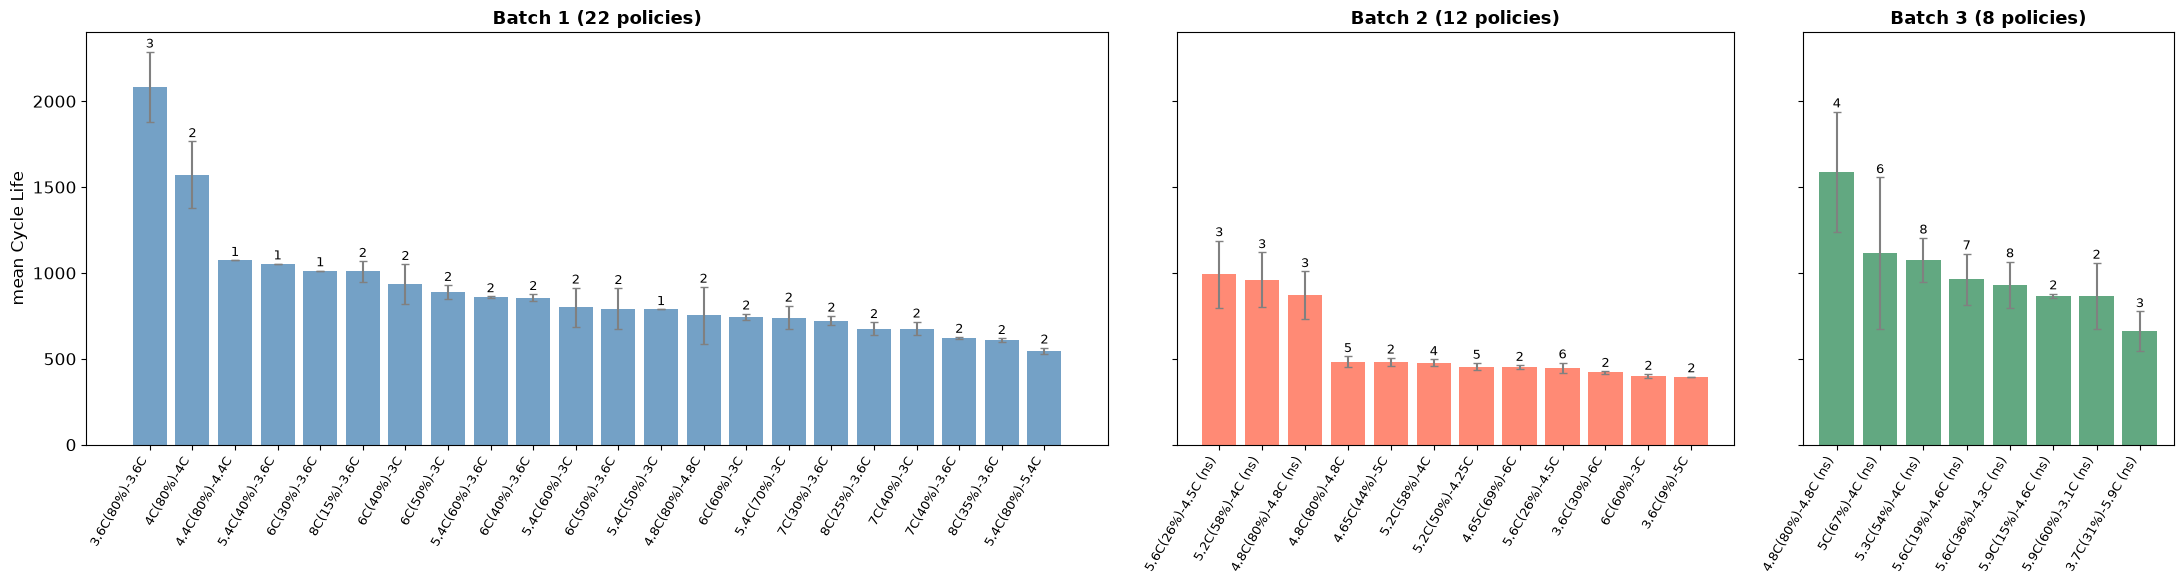

In [49]:
# 4-1. 충전 프로토콜별 평균 수명 (배치별, ± 1 std, 막대 위 숫자 = 셀 수)
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}
stats = {name: x.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
         for name, x in cells.groupby('batch')}
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True,
                         gridspec_kw={'width_ratios': [len(s) for s in stats.values()]})
for ax, (name, s) in zip(axes, stats.items()):
    labels = [p.replace('-newstructure', ' (ns)') for p in s.index]
    ax.bar(range(len(s)), s['mean'], yerr=s['std'].fillna(0), color=batch_colors[name], alpha=0.75,
           error_kw=dict(ecolor='gray', capsize=3))
    for k, (m, sd, n) in enumerate(zip(s['mean'], s['std'].fillna(0), s['count'])):
        ax.text(k, m + sd + 25, str(int(n)), ha='center', fontsize=9)
    ax.set_xticks(range(len(s))); ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=9)
    ax.set_title(f'{name} ({len(s)} policies)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('mean Cycle Life')
plt.tight_layout()
plt.show()


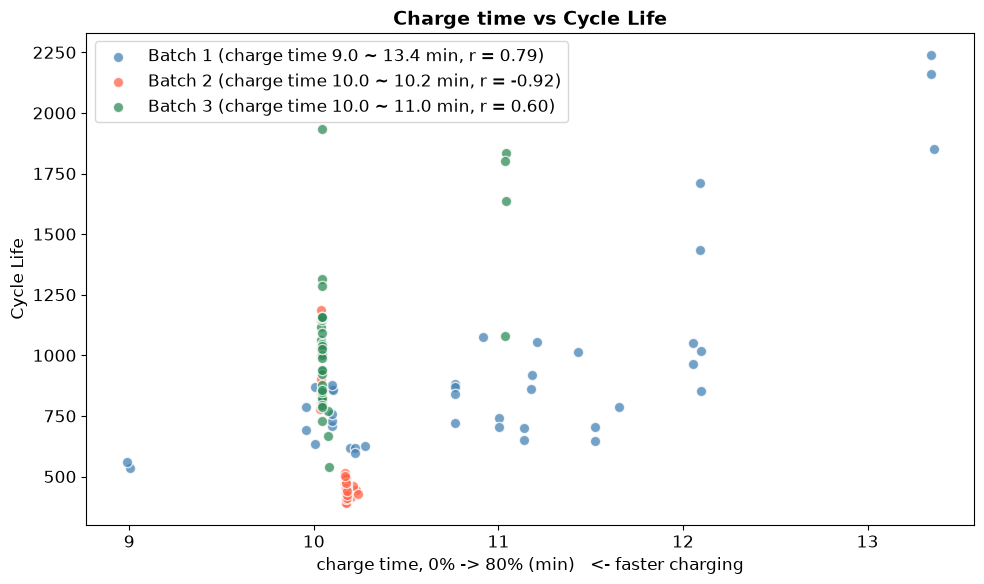

In [50]:
# 4-2. 충전 시간(0% -> 80%)과 수명 : 충전 시간이 짧을수록 고속 충전
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'tomato', 'Batch 3': 'seagreen'}
fig, ax = plt.subplots(figsize=(10, 6))
for name, x in cells.groupby('batch'):
    r = x['med_chargetime'].corr(x['cycle_life'])
    ax.scatter(x['med_chargetime'], x['cycle_life'], color=batch_colors[name], s=55, alpha=0.75, edgecolors='white',
               label=f"{name} (charge time {x['med_chargetime'].min():.1f} ~ {x['med_chargetime'].max():.1f} min, r = {r:.2f})")
ax.set_xlabel('charge time, 0% -> 80% (min)   <- faster charging')
ax.set_ylabel('Cycle Life')
ax.set_title('Charge time vs Cycle Life', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [51]:
# 4-3. 충전 전류 패턴 (1단계 속도 C1, 전환 시점 Q1, 2단계 속도 C2) 과 열화 속도의 상관
pol = cells['charging_policy'].str.extract(r'([\d.]+)C\((\d+)%\)-([\d.]+)C').astype(float)
cells['C1'], cells['Q1'], cells['C2'] = pol[0], pol[1], pol[2]
fix = (cells['batch'] == 'Batch 3') & cells['charging_policy'].str.startswith('4.8C(80%)-4.8C')
cells.loc[fix, ['C1', 'C2']] = 4.36            # 실제 충전 시간(약 11분)과 원논문 표 기준으로 보정
cells['fade_rate'] = (cells['QD_2'] - 0.88) / cells['cycle_life'] * 1000      # 평균 열화 속도 (mAh / cycle)
cells['early_fade'] = (cells['QD_2'] - cells['QD_100']) * 1000                # 초기 100 사이클 용량 감소 (mAh)

pattern = ['C1', 'Q1', 'C2']
targets = {'fade_rate': '평균 열화 속도', 'early_fade': '초기 100사이클 감소', 'log_dQ_var': 'log ΔQ 분산'}
tbl = pd.concat({name: x[pattern + list(targets)].corr().loc[pattern, list(targets)].rename(columns=targets)
                 for name, x in cells.groupby('batch')}).round(2)
display(tbl)


평균 열화 속도  초기 100사이클 감소  log ΔQ 분산
Batch 1 C1      0.61          0.20       0.66
        Q1     -0.27          0.09      -0.36
        C2      0.20          0.51       0.09
Batch 2 C1     -0.14         -0.24      -0.17
        Q1     -0.18         -0.20      -0.17
        C2      0.08          0.44       0.21
Batch 3 C1     -0.04         -0.69      -0.15
        Q1     -0.50         -0.21      -0.46
        C2      0.42          0.78       0.47

5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

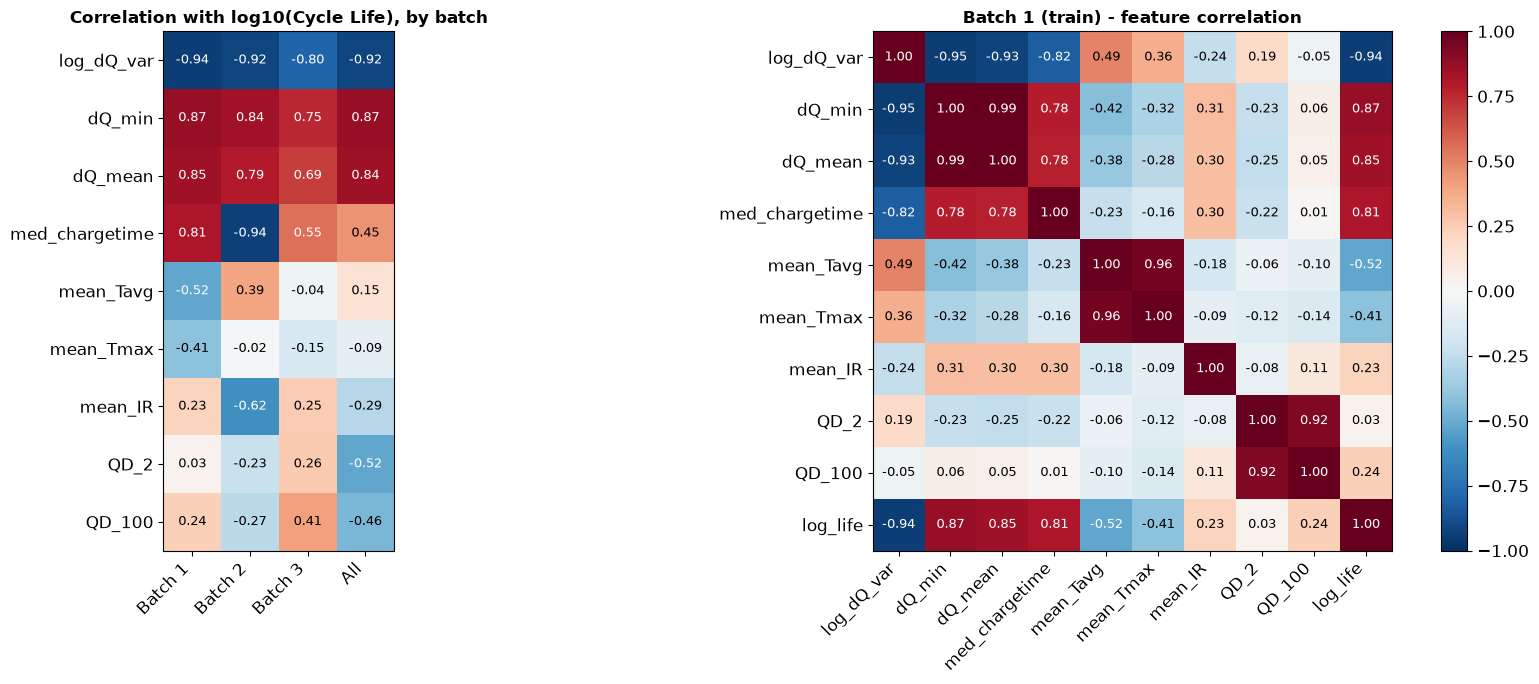

log10(cycle_life)와의 상관계수


,Batch 1,Batch 2,Batch 3,All
log_dQ_var,-0.94,-0.92,-0.80,-0.92
dQ_min,0.87,0.84,0.75,0.87
dQ_mean,0.85,0.79,0.69,0.84
med_chargetime,0.81,-0.94,0.55,0.45
mean_Tavg,-0.52,0.39,-0.04,0.15
mean_Tmax,-0.41,-0.02,-0.15,-0.09
mean_IR,0.23,-0.62,0.25,-0.29
QD_2,0.03,-0.23,0.26,-0.52
QD_100,0.24,-0.27,0.41,-0.46


In [38]:
# 5. 초기 100 사이클 피처와 수명의 상관관계 (배치별)
feats = ['log_dQ_var', 'dQ_min', 'dQ_mean', 'med_chargetime', 'mean_Tavg', 'mean_Tmax', 'mean_IR', 'QD_2', 'QD_100']
corr_tbl = pd.DataFrame({name: x[feats].corrwith(x['log_life']) for name, x in cells.groupby('batch')})
corr_tbl['All'] = cells[feats].corrwith(cells['log_life'])
b1_corr = cells.loc[cells['batch'] == 'Batch 1', feats + ['log_life']].corr()

def heatmap(ax, m, title):
    im = ax.imshow(m, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(m.shape[1])); ax.set_xticklabels(m.columns, rotation=45, ha='right')
    ax.set_yticks(range(m.shape[0])); ax.set_yticklabels(m.index)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.iloc[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9, color='white' if abs(v) > 0.5 else 'black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    return im

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={'width_ratios': [1, 1.6]})
heatmap(axes[0], corr_tbl, 'Correlation with log10(Cycle Life), by batch')
im = heatmap(axes[1], b1_corr, 'Batch 1 (train) - feature correlation')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print("log10(cycle_life)와의 상관계수")
display(corr_tbl.round(2))


[correlation] - 초기 100 사이클 피처와 log10(cycle life)
- 배치별 상관 (왼쪽) : Batch 1 / Batch 2 / Batch 3
    - ΔQ(V) 분산 : -0.94 / -0.92 / -0.80 -> 가장 강하고, 세 배치에서 방향이 같은 유일한 계열
    - ΔQ(V) 최솟값 0.87 / 0.84 / 0.75, 평균 0.85 / 0.79 / 0.69
    - 충전 시간 : +0.81 / -0.94 / +0.55 -> 배치마다 부호가 다름. Batch 2·3은 충전 시간이 거의 일정(약 10분)해서 작은 차이가 상관으로 나타난 것
    - 평균 온도 : -0.52 / +0.39 / -0.04, 평균 IR : +0.23 / -0.62 / +0.25 -> 부호가 일정하지 않음
    - 초기 용량 : cycle 2 +0.03 / -0.23 / +0.26, cycle 100 +0.24 / -0.27 / +0.41 -> 약함
- Batch 1 피처 간 상관 (오른쪽) : 다중공선성
    - ΔQ(V) 통계값끼리 : 분산-최솟값 -0.95, 최솟값-평균 0.99 -> 사실상 같은 정보
    - ΔQ(V) 분산-충전 시간 -0.82 -> Batch 1에서는 ΔQ(V)가 충전 조건과도 함께 움직임
    - 평균 온도-최고 온도 0.96, cycle 2 용량-cycle 100 용량 0.92

[to modeling]
- 배치가 바뀌어도 유지되는 신호는 ΔQ(V) 계열뿐 -> ΔQ(V) 분산을 중심으로 소수의 피처만 사용
- 충전 시간·온도·IR은 Batch 1에서의 관계가 Batch 2·3에서 유지되지 않음 -> 넣더라도 보조 피처로만, Hold-out과 Batch 2에서 효과를 확인
- 서로 상관이 높은 피처 묶음(ΔQ 통계값 3종, 온도 2종, 용량 2종)은 묶음당 하나만 쓰거나 규제 선형 모델 사용
- 학습 셀이 41개뿐이므로 피처 수를 적게 유지 (원논문도 ΔQ 분산 하나만 쓴 모델과 elastic net을 사용)


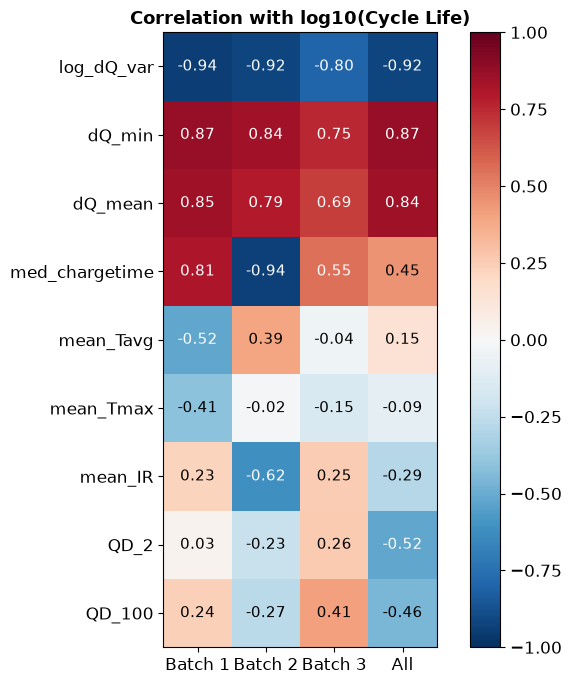

In [52]:
# 5-1. 초기 100 사이클 피처와 log10(Cycle Life)의 상관계수 (배치별)
feats = ['log_dQ_var', 'dQ_min', 'dQ_mean', 'med_chargetime', 'mean_Tavg', 'mean_Tmax', 'mean_IR', 'QD_2', 'QD_100']
corr_tbl = pd.DataFrame({name: x[feats].corrwith(x['log_life']) for name, x in cells.groupby('batch')})
corr_tbl['All'] = cells[feats].corrwith(cells['log_life'])

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(corr_tbl, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(corr_tbl.shape[1])); ax.set_xticklabels(corr_tbl.columns)
ax.set_yticks(range(corr_tbl.shape[0])); ax.set_yticklabels(corr_tbl.index)
for i in range(corr_tbl.shape[0]):
    for j in range(corr_tbl.shape[1]):
        v = corr_tbl.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=11, color='white' if abs(v) > 0.5 else 'black')
ax.set_title('Correlation with log10(Cycle Life)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


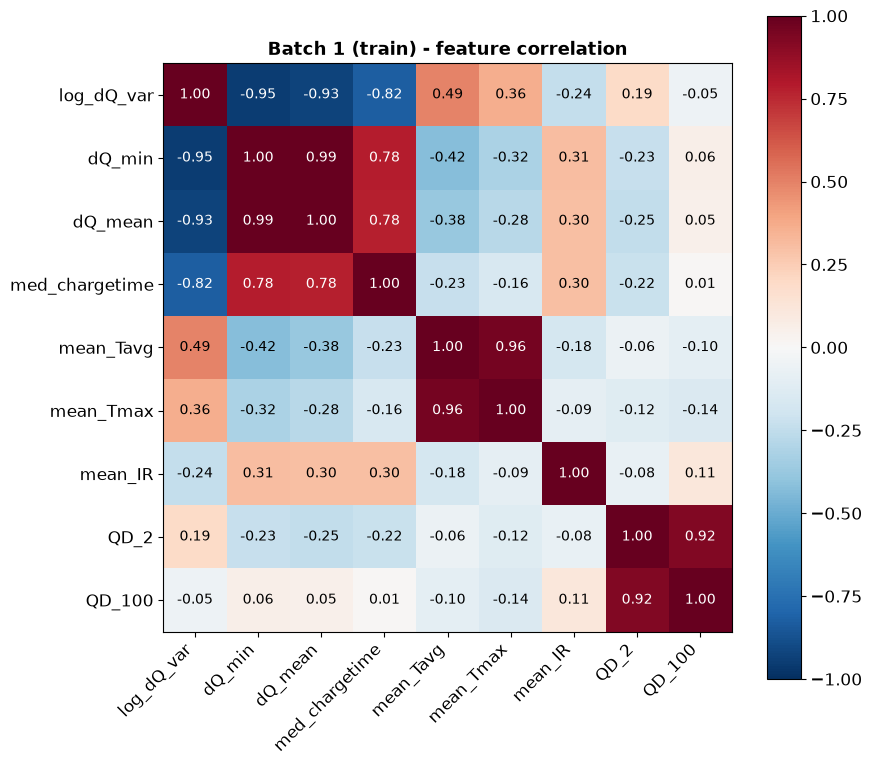

,feature 1,feature 2,corr
0,log_dQ_var,dQ_min,-0.95
1,log_dQ_var,dQ_mean,-0.93
2,log_dQ_var,med_chargetime,-0.82
3,dQ_min,dQ_mean,0.99
4,dQ_min,med_chargetime,0.78
5,dQ_mean,med_chargetime,0.78
6,mean_Tavg,mean_Tmax,0.96
7,QD_2,QD_100,0.92


In [53]:
# 5-3. Batch 1(학습) 피처 간 상관계수
feats = ['log_dQ_var', 'dQ_min', 'dQ_mean', 'med_chargetime', 'mean_Tavg', 'mean_Tmax', 'mean_IR', 'QD_2', 'QD_100']
b1_corr = cells.loc[cells['batch'] == 'Batch 1', feats].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(b1_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha='right')
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats)
for i in range(len(feats)):
    for j in range(len(feats)):
        v = b1_corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10, color='white' if abs(v) > 0.5 else 'black')
ax.set_title('Batch 1 (train) - feature correlation', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# 상관계수 절댓값이 0.7을 넘는 피처 쌍
pairs = [(a, b, round(b1_corr.loc[a, b], 2)) for i, a in enumerate(feats) for b in feats[i + 1:] if abs(b1_corr.loc[a, b]) > 0.7]
display(pd.DataFrame(pairs, columns=['feature 1', 'feature 2', 'corr']))
